<a href="https://colab.research.google.com/github/GalihPattiaSattiRepriyanti195/UTS_DataMining_GALIH-PATTIA-SATTI-REPRIYANTI_2304020195/blob/main/1srweektasks/UTS_DataMining_GALIH_PATTIA_SATTI_REPRIYANTI_2304020195.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Persiapan Lingkungan dan Data**

Langkah awal adalah mengimpor library yang diperlukan dan mengunduh dataset melalui tautan yang disediakan di soal.

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Mengunduh dataset dari tautan bit.ly/datasetwine
# Pastikan Anda telah mengunduh file dataset_training.csv dan data_testing.csv ke local/colab
df_train = pd.read_csv('/content/data_training.csv')
df_test = pd.read_csv('/content/data_testing.csv')

print("Data Training Berhasil Dimuat.")

Data Training Berhasil Dimuat.


**2. Pembersihan Data (Data Cleaning)**

Sesuai instruksi nomor 2, kita harus memastikan tidak ada missing values dan melakukan feature scaling.

In [15]:
# Cek Missing Values [cite: 27]
print("Jumlah Missing Values (Train):\n", df_train.isnull().sum())
print("\nJumlah Missing Values (Test):\n", df_test.isnull().sum())

# Penanganan Missing Values (Imputasi dengan Median jika ada) [cite: 28]
if df_train.isnull().values.any():
    df_train = df_train.fillna(df_train.median())
if df_test.isnull().values.any():
    df_test = df_test.fillna(df_test.median())

# Memisahkan Fitur dan Target (drop kolom 'Id' dan 'quality' dari X)
# Pastikan kolom 'Id' juga dihapus dari data training sebelum scaling
X = df_train.drop(columns=['Id', 'quality'])
y = df_train['quality']

# Feature Scaling menggunakan StandardScaler [cite: 29]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Siapkan data testing untuk prediksi akhir (hilangkan kolom Id jika ada)
X_test_final = df_test.drop(columns=['Id']) # Mengubah 'id' menjadi 'Id'
X_test_final_scaled = scaler.transform(X_test_final)

Jumlah Missing Values (Train):
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Jumlah Missing Values (Test):
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


**3. Pembuatan dan Evaluasi Model**

Gunakan model klasifikasi untuk memprediksi quality. Di sini kita menggunakan Random Forest karena keakuratannya yang tinggi pada data tabular.

In [11]:
# Split data training untuk validasi (80% Train, 20% Val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Inisialisasi Model [cite: 38]
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Evaluasi Model menggunakan Akurasi dan Confusion Matrix [cite: 39]
y_pred_val = model.predict(X_val)
print(f"Akurasi Validasi: {accuracy_score(y_val, y_pred_val)}")
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred_val))

Akurasi Validasi: 0.6046511627906976

Confusion Matrix:
 [[ 0  1  2  0  0]
 [ 0 44 23  0  0]
 [ 0 23 52  3  0]
 [ 0  2 11  8  0]
 [ 0  0  0  3  0]]


**4. Prediksi Data Uji (Testing)**

Gunakan model untuk memprediksi data dari file data_testing.csv.

In [16]:
# Prediksi data uji [cite: 41]
final_predictions = model.predict(X_test_final_scaled)

# Menyusun hasil sesuai format: HANYA kolom 'Id' dan 'quality' [cite: 19, 43, 47]
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': final_predictions
})

# Simpan ke CSV dengan format penamaan: hasilprediksi_3NIMterakhir.csv
nim_terakhir = "XXX" # GANTI DENGAN 3 DIGIT TERAKHIR NIM ANDA
nama_file = f"hasilprediksi_{nim_terakhir}.csv"
submission.to_csv(nama_file, index=False)

print(f"File {nama_file} siap diunduh.")

File hasilprediksi_XXX.csv siap diunduh.


### Visualisasi Distribusi Kolom 'quality'

Visualisasi ini akan menunjukkan sebaran nilai-nilai pada kolom 'quality' di `df_train` untuk memahami distribusi kualitas wine.

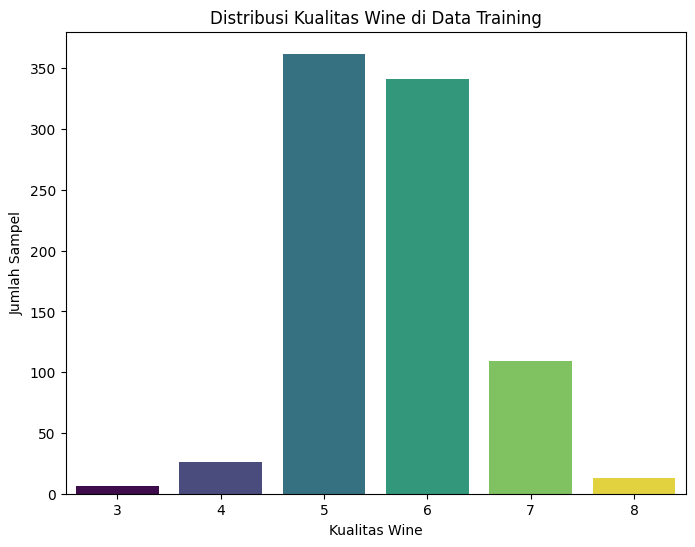

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df_train, palette='viridis', hue='quality', legend=False)
plt.title('Distribusi Kualitas Wine di Data Training')
plt.xlabel('Kualitas Wine')
plt.ylabel('Jumlah Sampel')
plt.show()

### Statistik Deskriptif df_train

Berikut adalah ringkasan statistik deskriptif untuk setiap kolom numerik dalam `df_train`, yang memberikan gambaran tentang pusat, sebaran, dan bentuk distribusi data.

In [31]:
display(df_train.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


In [18]:
display(df_train.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


### Statistik Deskriptif untuk 'Alcohol' dan 'Volatile Acidity'

Berikut adalah ringkasan statistik deskriptif untuk kolom 'alcohol' dan 'volatile acidity' dalam `df_train`.

In [39]:
display(df_train[['alcohol', 'volatile acidity']].describe())

,alcohol,volatile acidity
count,857.000000,857.000000
mean,10.430338,0.529393
std,1.066971,0.179162
min,8.400000,0.120000
25%,9.500000,0.395000
50%,10.200000,0.520000
75%,11.100000,0.640000
max,14.000000,1.580000


### Identifikasi Fitur Paling Berpengaruh

Bagian ini akan menampilkan fitur-fitur yang paling berpengaruh terhadap kualitas wine berdasarkan nilai `feature_importances_` dari model Random Forest. Fitur-fitur dengan nilai `feature_importances_` yang lebih tinggi menunjukkan kontribusi yang lebih besar dalam memprediksi kualitas wine.

In [19]:
import pandas as pd

# Mendapatkan feature importances dari model
feature_importances = model.feature_importances_

# Mendapatkan nama-nama fitur dari DataFrame X
feature_names = X.columns

# Membuat DataFrame untuk feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Mengurutkan fitur berdasarkan kepentingannya secara menurun
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Fitur Paling Berpengaruh terhadap Kualitas Wine:")
display(feature_importance_df)

Fitur Paling Berpengaruh terhadap Kualitas Wine:


,Feature,Importance
10,alcohol,0.139281
9,sulphates,0.122799
1,volatile acidity,0.110338
6,total sulfur dioxide,0.105630
7,density,0.084770
4,chlorides,0.080142
8,pH,0.077190
2,citric acid,0.074695
0,fixed acidity,0.074188
3,residual sugar,0.066638


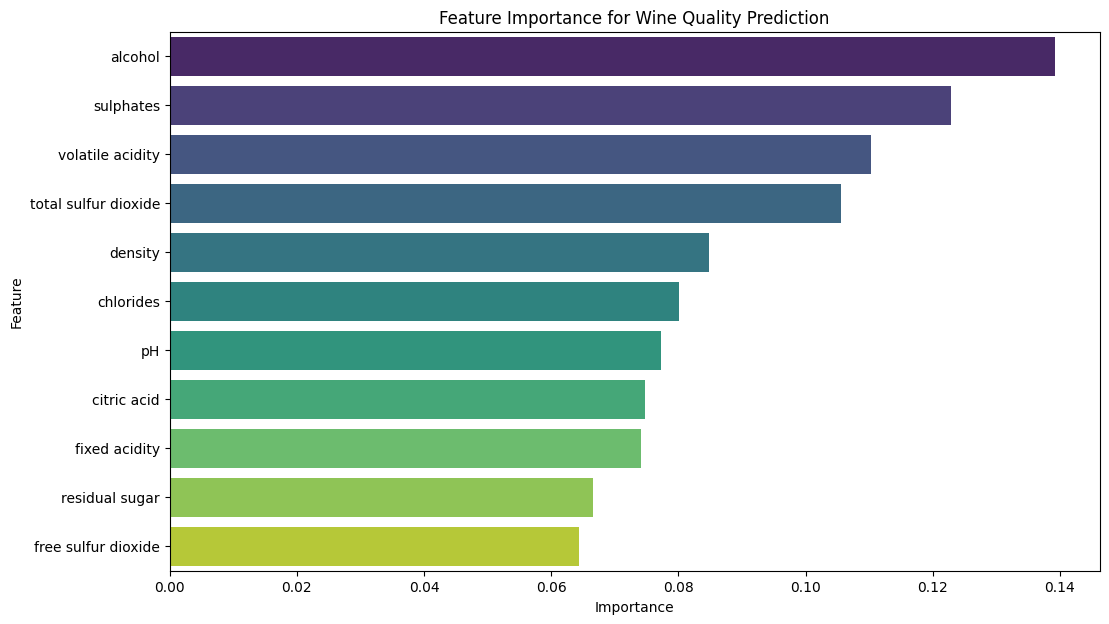

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance for Wine Quality Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Visualisasi Scatter Plot: Alcohol vs. Quality

Scatter plot ini akan menunjukkan hubungan antara kadar alkohol dan kualitas wine, membantu kita mengidentifikasi tren atau pola yang mungkin ada.

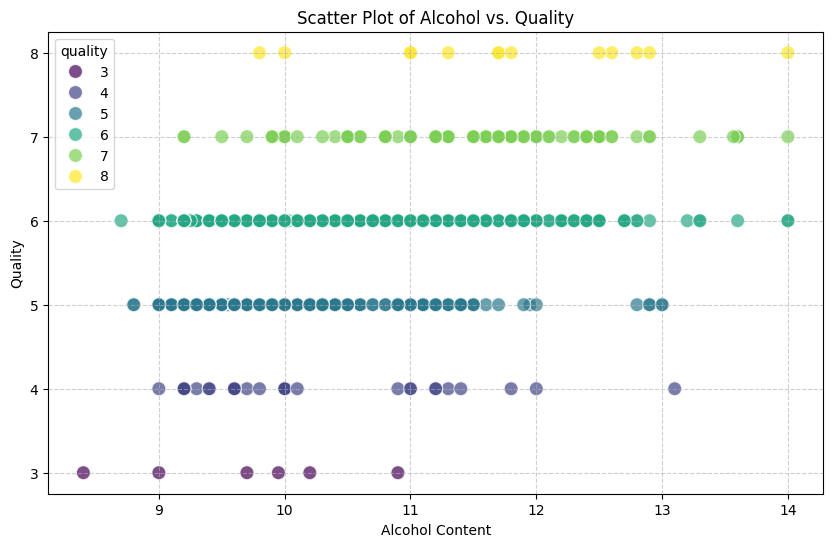

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='quality', data=df_train, hue='quality', palette='viridis', s=100, alpha=0.7)
plt.title('Scatter Plot of Alcohol vs. Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Quality')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Histogram: Distribusi Kualitas Wine

Histogram ini akan menampilkan sebaran frekuensi dari setiap nilai 'quality' dalam dataset, memberikan gambaran yang lebih detail mengenai distribusi kualitas wine.

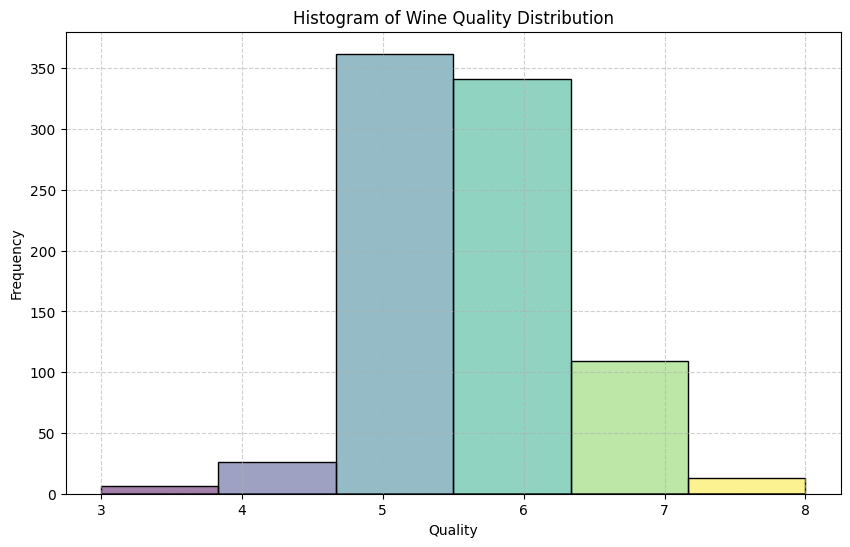

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(x='quality', data=df_train, kde=True, bins=len(df_train['quality'].unique()), palette='viridis', hue='quality', legend=False)
plt.title('Histogram of Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.xticks(sorted(df_train['quality'].unique()))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Rata-rata Kualitas Berdasarkan Kategori Alkohol

Bagian ini akan mengelompokkan anggur berdasarkan kategori kadar alkohol dan menghitung rata-rata kualitas untuk setiap kategori. Ini akan membantu kita melihat bagaimana perubahan kadar alkohol memengaruhi penilaian kualitas secara rata-rata.

In [44]:
# Tentukan batas-batas kategori alkohol (bins)
alcohol_bins = [8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0] # Sesuaikan berdasarkan rentang data
labels = ['8.0-8.9', '9.0-9.9', '10.0-10.9', '11.0-11.9', '12.0-12.9', '13.0-13.9', '14.0-14.9']

# Buat kolom kategori alkohol baru
df_train['alcohol_category'] = pd.cut(df_train['alcohol'], bins=alcohol_bins, labels=labels, right=False)

# Hitung rata-rata kualitas untuk setiap kategori alkohol
average_quality_by_alcohol = df_train.groupby('alcohol_category', observed=True)['quality'].mean().reset_index()

display(average_quality_by_alcohol)

,alcohol_category,quality
0,8.0-8.9,4.750000
1,9.0-9.9,5.289694
2,10.0-10.9,5.679487
3,11.0-11.9,6.033898
4,12.0-12.9,6.417910
5,13.0-13.9,6.083333
6,14.0-14.9,6.750000


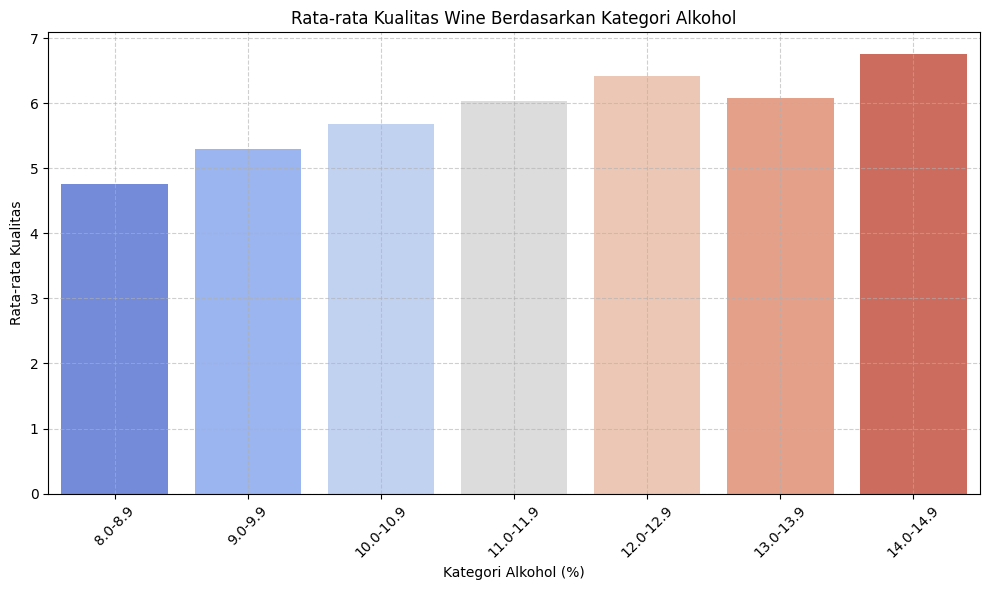

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='alcohol_category', y='quality', data=average_quality_by_alcohol, palette='coolwarm', hue='alcohol_category', legend=False)
plt.title('Rata-rata Kualitas Wine Berdasarkan Kategori Alkohol')
plt.xlabel('Kategori Alkohol (%)')
plt.ylabel('Rata-rata Kualitas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning dengan GridSearchCV

Kita akan menggunakan `GridSearchCV` untuk mencari kombinasi hyperparameter terbaik untuk model Random Forest, yang dapat meningkatkan akurasi prediktif.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definisikan parameter grid yang akan dicari
param_grid = {
    'n_estimators': [100, 200, 300], # Jumlah pohon dalam forest
    'max_depth': [None, 10, 20, 30], # Kedalaman maksimum pohon
    'min_samples_split': [2, 5, 10], # Jumlah minimum sampel yang diperlukan untuk memecah simpul internal
    'min_samples_leaf': [1, 2, 4] # Jumlah minimum sampel yang diperlukan untuk menjadi simpul daun
}

# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Inisialisasi GridSearchCV
# cv=5 berarti 5-fold cross-validation
# n_jobs=-1 berarti menggunakan semua core prosesor yang tersedia
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Lakukan fitting GridSearchCV ke data training yang sudah discale
grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best accuracy found:", grid_search.best_score_)

# Model terbaik
best_rf_model = grid_search.best_estimator_

# Evaluasi model terbaik pada validation set
y_pred_val_tuned = best_rf_model.predict(X_val)
print(f"\nAkurasi Validasi dengan Model Terbaik: {accuracy_score(y_val, y_pred_val_tuned)}")
print("Confusion Matrix dengan Model Terbaik:\n", confusion_matrix(y_val, y_pred_val_tuned))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best accuracy found: 0.6452554744525547

Akurasi Validasi dengan Model Terbaik: 0.6046511627906976
Confusion Matrix dengan Model Terbaik:
 [[ 0  1  2  0  0]
 [ 0 44 23  0  0]
 [ 0 22 52  4  0]
 [ 0  2 11  8  0]
 [ 0  0  0  3  0]]


### Melatih Model dengan XGBoost

Sekarang kita akan melatih model menggunakan algoritma Gradient Boosting, khususnya XGBoost, dan mengevaluasinya.

In [25]:
import xgboost as xgb

# Adjust y_train and y_val to be zero-indexed for XGBoost
# The original quality values are [3, 4, 5, 6, 7, 8]. Subtracting 3 will make them [0, 1, 2, 3, 4, 5].
min_quality_value = y_train.min()
y_train_adjusted = y_train - min_quality_value
y_val_adjusted = y_val - min_quality_value

# Inisialisasi Model XGBoost
# Menggunakan parameter default atau bisa disesuaikan lebih lanjut
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y_train_adjusted)),
                              eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# Latih model
xgb_model.fit(X_train, y_train_adjusted)

# Evaluasi Model XGBoost pada validation set
y_pred_val_xgb = xgb_model.predict(X_val)
print(f"Akurasi Validasi XGBoost: {accuracy_score(y_val_adjusted, y_pred_val_xgb)}")
print("\nConfusion Matrix XGBoost:\n", confusion_matrix(y_val_adjusted, y_pred_val_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:04:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Akurasi Validasi XGBoost: 0.6337209302325582

Confusion Matrix XGBoost:
 [[ 0  1  2  0  0]
 [ 0 46 21  0  0]
 [ 1 17 51  9  0]
 [ 0  2  6 12  1]
 [ 0  0  0  3  0]]


In [26]:
# Prediksi data uji menggunakan model XGBoost
final_predictions_xgb = xgb_model.predict(X_test_final_scaled)

# Mengembalikan prediksi ke skala asli sebelum disimpan
# Tambahkan kembali nilai minimum yang dikurangkan sebelumnya
final_predictions_xgb_original_scale = final_predictions_xgb + min_quality_value

# Menyusun hasil sesuai format: HANYA kolom 'Id' dan 'quality'
submission_xgb = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': final_predictions_xgb_original_scale
})

# Simpan ke CSV dengan format penamaan: hasilprediksi_3NIMterakhir_xgb.csv
nim_terakhir_xgb = "XXX" # GANTI DENGAN 3 DIGIT TERAKHIR NIM ANDA
nama_file_xgb = f"hasilprediksi_{nim_terakhir_xgb}_xgb.csv"
submission_xgb.to_csv(nama_file_xgb, index=False)

print(f"File {nama_file_xgb} siap diunduh.")

File hasilprediksi_XXX_xgb.csv siap diunduh.


### Prediksi Kualitas Anggur pada Data Uji dengan Model XGBoost

Berdasarkan instruksi, langkah terakhir adalah menggunakan model klasifikasi terbaik yang telah dilatih (dalam kasus ini, XGBoost karena akurasi validasinya lebih tinggi) untuk memprediksi kualitas anggur pada `data_testing.csv` dan menghasilkan file submission.

In [45]:
# Prediksi data uji menggunakan model XGBoost yang sudah dilatih
# X_test_final_scaled sudah disiapkan di awal notebook
final_predictions_xgb = xgb_model.predict(X_test_final_scaled)

# Mengembalikan prediksi ke skala asli (menambahkan kembali nilai minimum yang dikurangkan)
# Ini penting karena target y_train dan y_val di-adjust ke zero-indexed untuk XGBoost
min_quality_value = y_train.min() # Mendapatkan nilai minimum dari y_train asli
final_predictions_xgb_original_scale = final_predictions_xgb + min_quality_value

# Menyusun hasil sesuai format: HANYA kolom 'Id' dan 'quality'
submission_xgb = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': final_predictions_xgb_original_scale
})

# Simpan ke CSV dengan format penamaan: hasilprediksi_3NIMterakhir_xgb.csv
nim_terakhir_xgb = "XXX" # GANTI DENGAN 3 DIGIT TERAKHIR NIM ANDA
nama_file_xgb = f"hasilprediksi_{nim_terakhir_xgb}_xgb.csv"
submission_xgb.to_csv(nama_file_xgb, index=False)

print(f"File '{nama_file_xgb}' berhasil dibuat dan siap diunduh. Pastikan untuk mengganti 'XXX' dengan 3 digit NIM terakhir Anda.")

File 'hasilprediksi_XXX_xgb.csv' berhasil dibuat dan siap diunduh. Pastikan untuk mengganti 'XXX' dengan 3 digit NIM terakhir Anda.


### Visualisasi Perbandingan Akurasi Model

Visualisasi ini akan menunjukkan perbandingan akurasi validasi antara model Random Forest yang telah di-tuning dan model XGBoost.

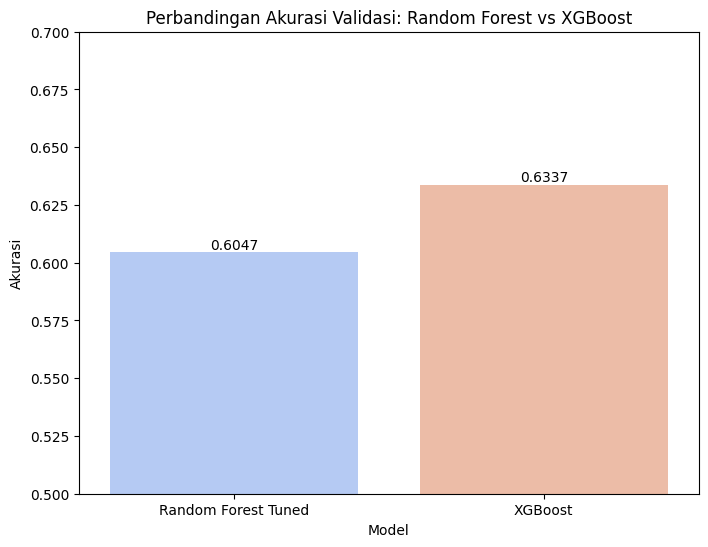

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Akurasi yang didapat dari evaluasi sebelumnya
rf_accuracy = 0.6046511627906976 # Akurasi Validasi RF dari cell 70874d79
xgb_accuracy = 0.6337209302325582 # Akurasi Validasi XGBoost dari cell 7e72885f

# Buat DataFrame untuk visualisasi
data = {
    'Model': ['Random Forest Tuned', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy]
}
df_accuracy = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=df_accuracy, palette='coolwarm', hue='Model', legend=False)
plt.ylim(0.5, 0.7) # Sesuaikan batas y agar perbandingan lebih jelas
plt.title('Perbandingan Akurasi Validasi: Random Forest vs XGBoost')
plt.xlabel('Model')
plt.ylabel('Akurasi')

# Menampilkan nilai akurasi di atas bar
for index, row in df_accuracy.iterrows():
    plt.text(row.name, row.Accuracy, f'{row.Accuracy:.4f}', color='black', ha="center", va='bottom')

plt.show()

### Analisis Feature Importance Model XGBoost

Bagian ini akan menampilkan fitur-fitur yang paling berpengaruh terhadap kualitas wine berdasarkan nilai `feature_importances_` dari model XGBoost. Fitur-fitur dengan nilai `feature_importances_` yang lebih tinggi menunjukkan kontribusi yang lebih besar dalam memprediksi kualitas wine.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mendapatkan feature importances dari model XGBoost
xgb_feature_importances = xgb_model.feature_importances_

# Mendapatkan nama-nama fitur dari DataFrame X (fitur yang sama digunakan)
xgb_feature_names = X.columns

# Membuat DataFrame untuk feature importances XGBoost
xgb_feature_importance_df = pd.DataFrame({
    'Feature': xgb_feature_names,
    'Importance': xgb_feature_importances
})

# Mengurutkan fitur berdasarkan kepentingannya secara menurun
xgb_feature_importance_df = xgb_feature_importance_df.sort_values(by='Importance', ascending=False)

print("Fitur Paling Berpengaruh terhadap Kualitas Wine (XGBoost):")
display(xgb_feature_importance_df)

Fitur Paling Berpengaruh terhadap Kualitas Wine (XGBoost):


,Feature,Importance
10,alcohol,0.160952
1,volatile acidity,0.124296
9,sulphates,0.117519
6,total sulfur dioxide,0.089679
5,free sulfur dioxide,0.084557
8,pH,0.079359
4,chlorides,0.075480
0,fixed acidity,0.072269
3,residual sugar,0.070229
7,density,0.063952


### Visualisasi Perbandingan Distribusi 'Alcohol' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi kadar alkohol antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

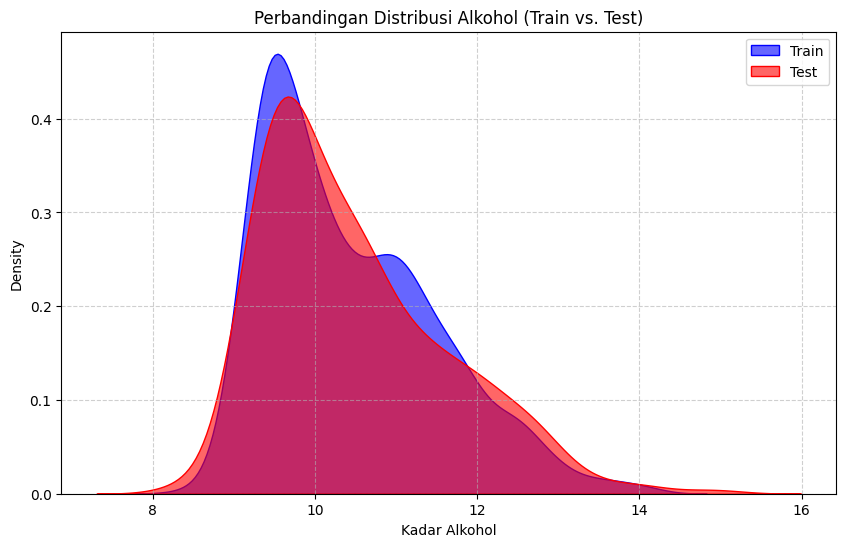

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['alcohol'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['alcohol'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Alkohol (Train vs. Test)')
plt.xlabel('Kadar Alkohol')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

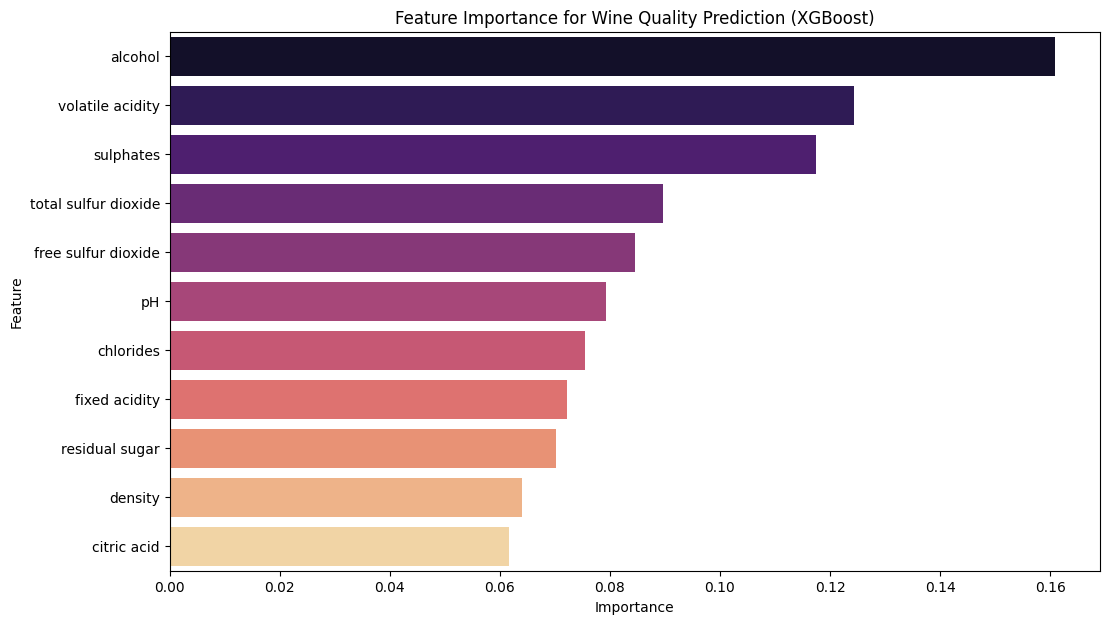

In [29]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance for Wine Quality Prediction (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Visualisasi Perbandingan Distribusi 'Volatile Acidity' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi kadar `volatile acidity` antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

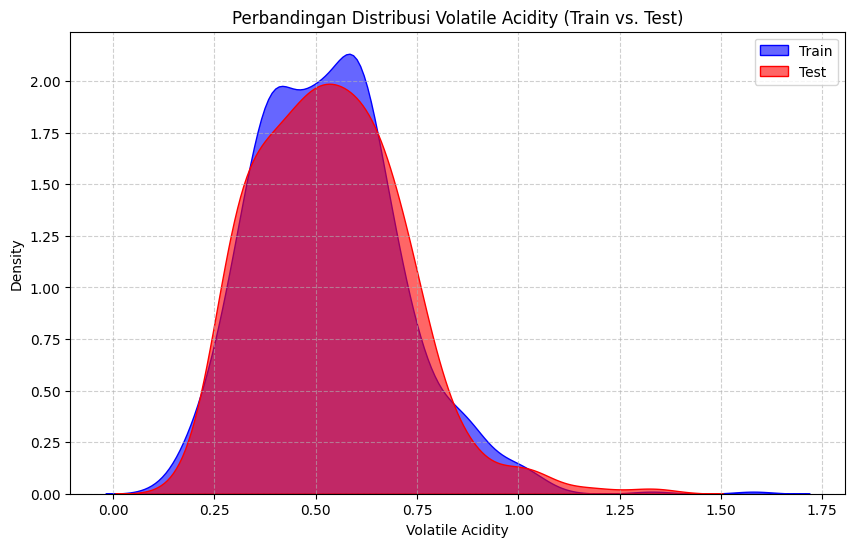

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['volatile acidity'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['volatile acidity'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Volatile Acidity (Train vs. Test)')
plt.xlabel('Volatile Acidity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'pH' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'pH' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

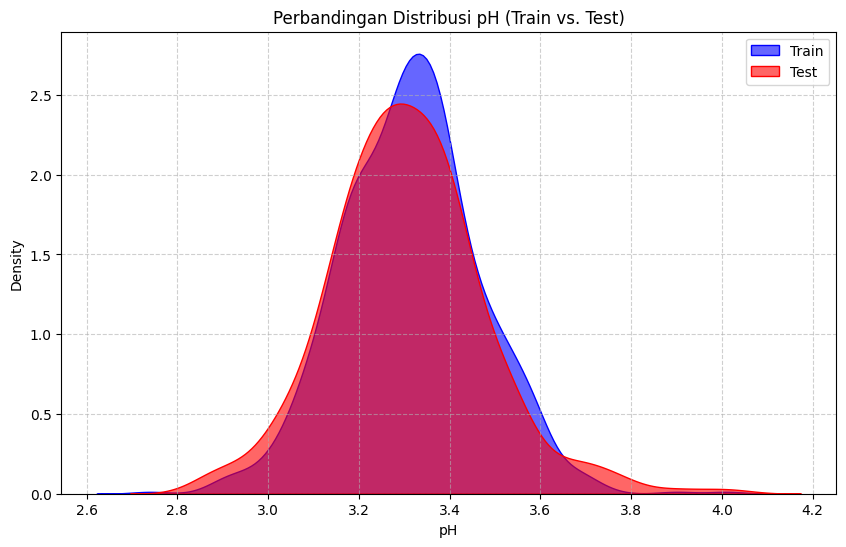

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['pH'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['pH'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi pH (Train vs. Test)')
plt.xlabel('pH')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Citric Acid' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'citric acid' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

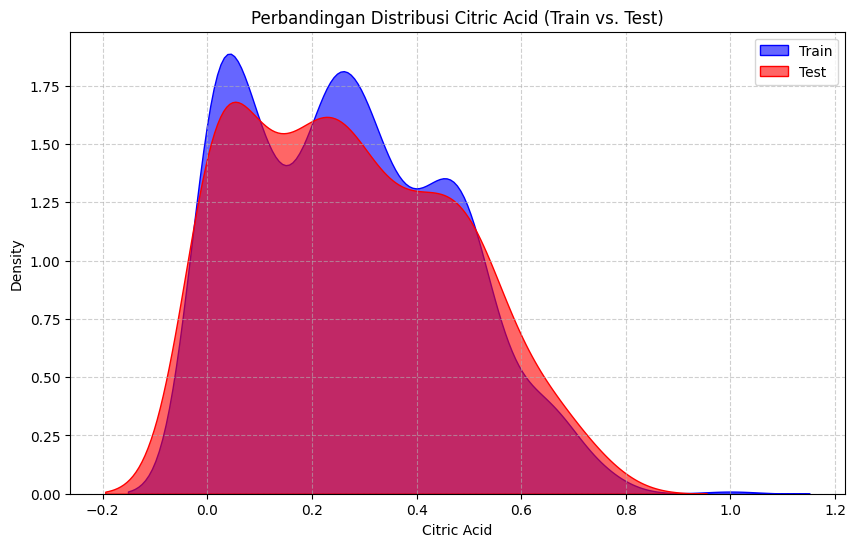

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['citric acid'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['citric acid'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Citric Acid (Train vs. Test)')
plt.xlabel('Citric Acid')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Citric Acid' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'citric acid' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

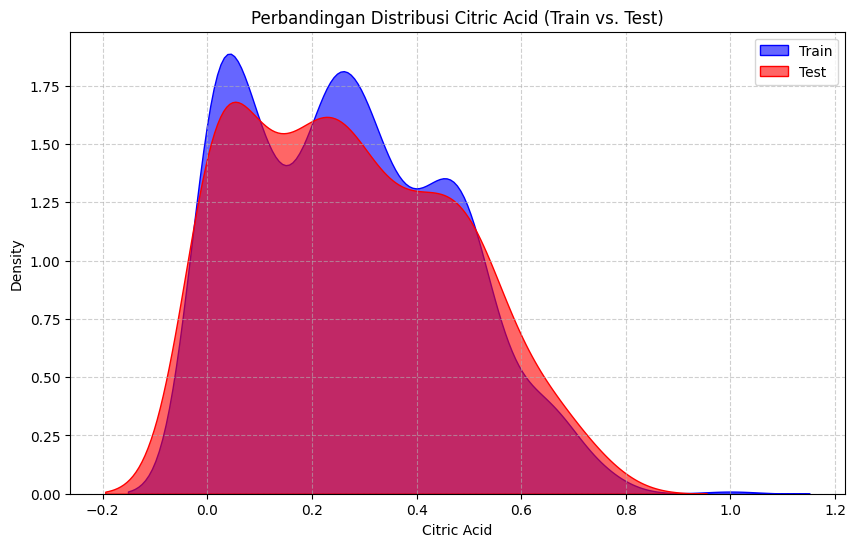

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['citric acid'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['citric acid'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Citric Acid (Train vs. Test)')
plt.xlabel('Citric Acid')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Chlorides' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'chlorides' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

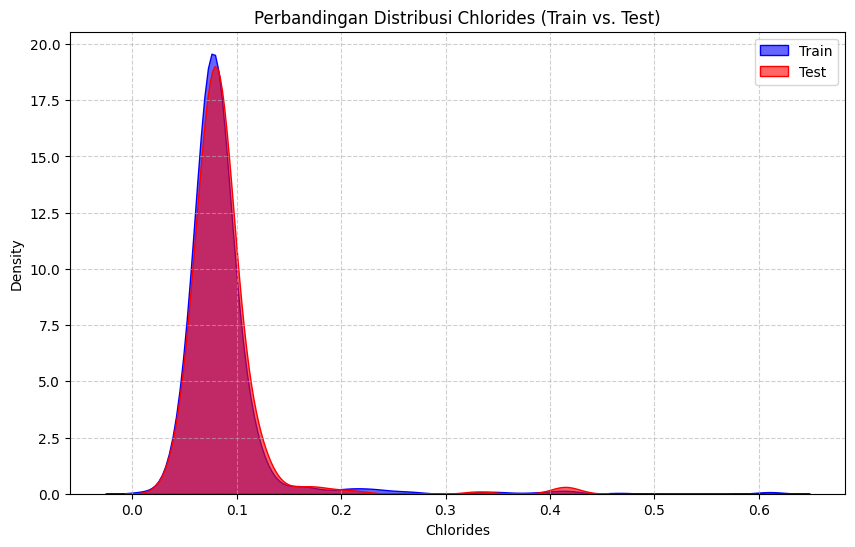

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['chlorides'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['chlorides'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Chlorides (Train vs. Test)')
plt.xlabel('Chlorides')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Free Sulfur Dioxide' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'free sulfur dioxide' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

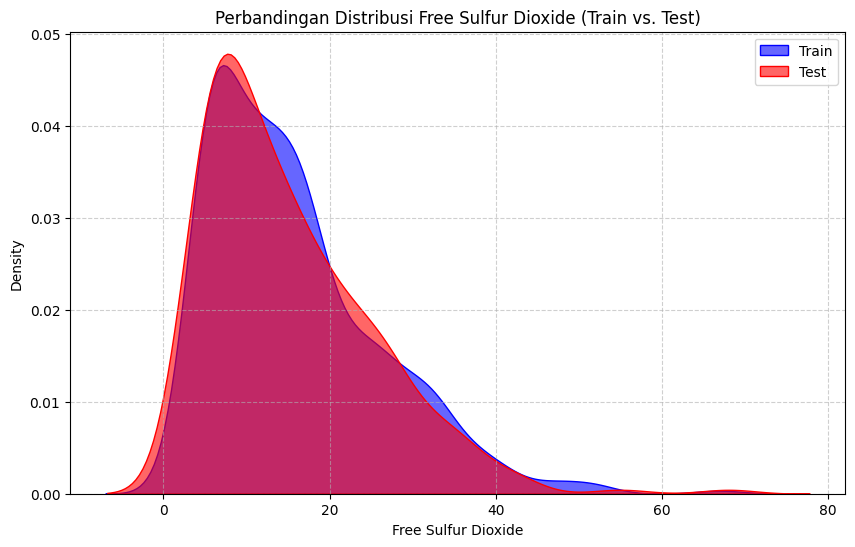

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['free sulfur dioxide'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['free sulfur dioxide'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Free Sulfur Dioxide (Train vs. Test)')
plt.xlabel('Free Sulfur Dioxide')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Correlation Heatmap

Bagian ini akan menampilkan correlation heatmap untuk melihat hubungan antar fitur dalam data training, termasuk kolom target 'quality'. Ini membantu mengidentifikasi multikolinearitas dan memahami interaksi antar variabel.

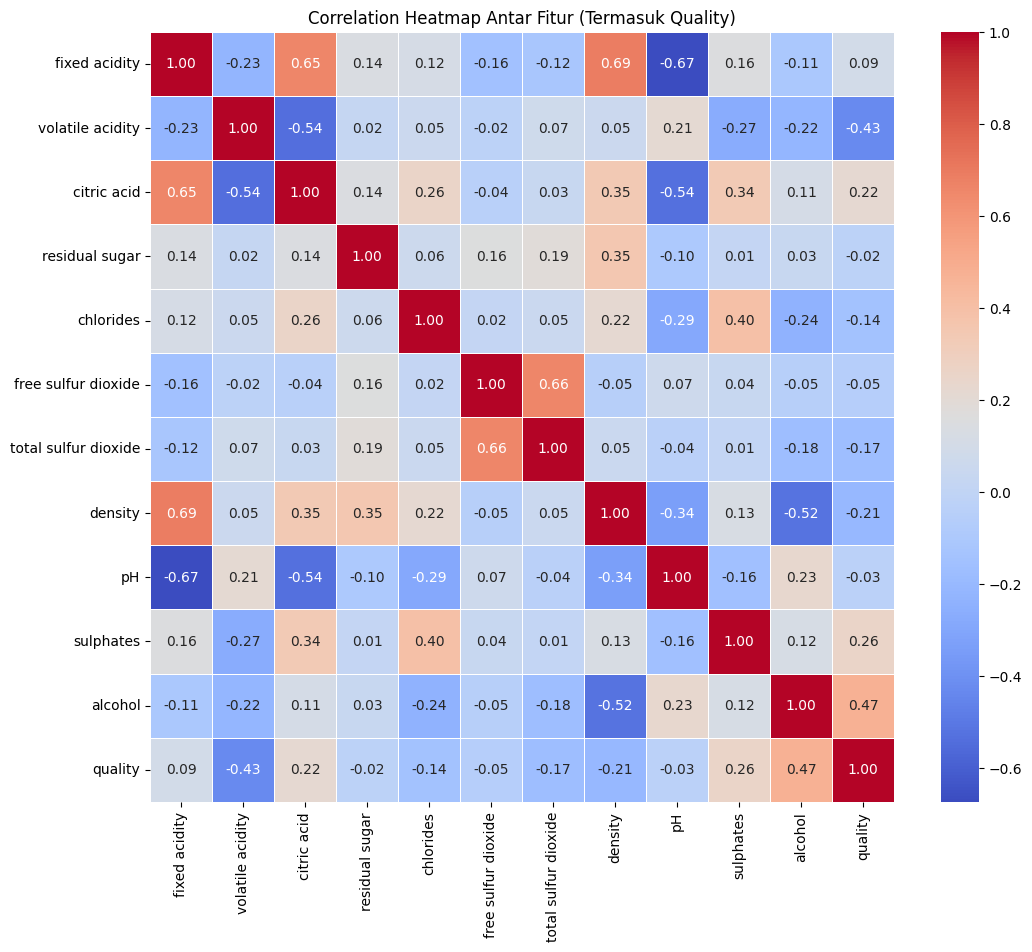

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung matriks korelasi. Drop 'Id' karena bukan fitur yang relevan untuk korelasi.
# Juga drop 'alcohol_category' karena ini adalah kolom kategorikal yang baru dibuat dan bukan fitur asli numerik.
correlation_matrix = df_train.drop(columns=['Id', 'alcohol_category'], errors='ignore').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap Antar Fitur (Termasuk Quality)')
plt.show()

### Visualisasi Perbandingan Distribusi 'Sulphates' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'sulphates' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

### Visualisasi Perbandingan Distribusi 'Fixed Acidity' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'fixed acidity' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

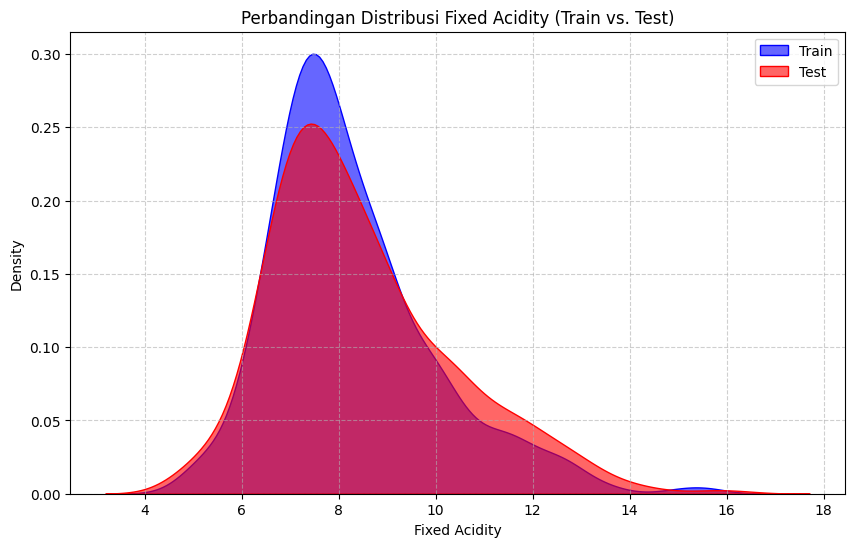

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['fixed acidity'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['fixed acidity'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Fixed Acidity (Train vs. Test)')
plt.xlabel('Fixed Acidity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Volatile Acidity' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'volatile acidity' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

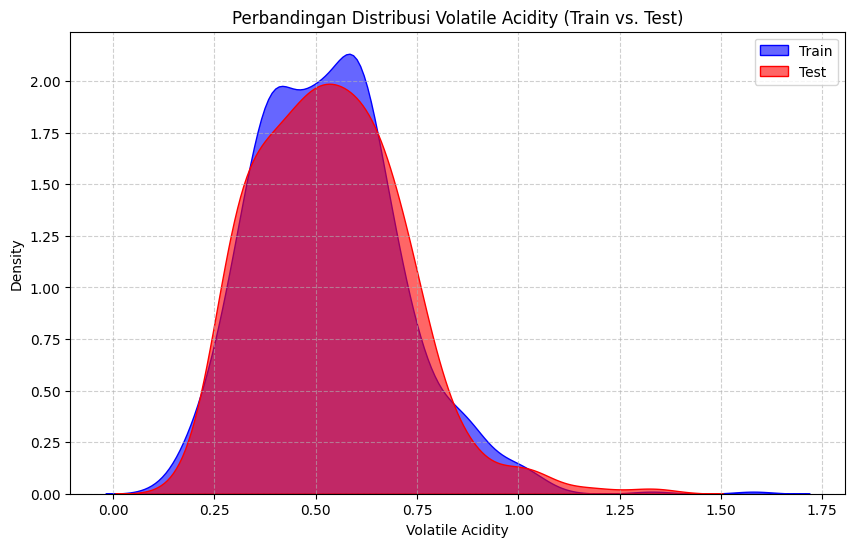

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['volatile acidity'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['volatile acidity'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Volatile Acidity (Train vs. Test)')
plt.xlabel('Volatile Acidity')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Perbandingan Distribusi 'Residual Sugar' (Train vs. Test)

KDE plot ini akan menunjukkan perbandingan distribusi 'residual sugar' antara data training dan data testing, membantu kita melihat apakah kedua dataset memiliki karakteristik yang serupa untuk fitur ini.

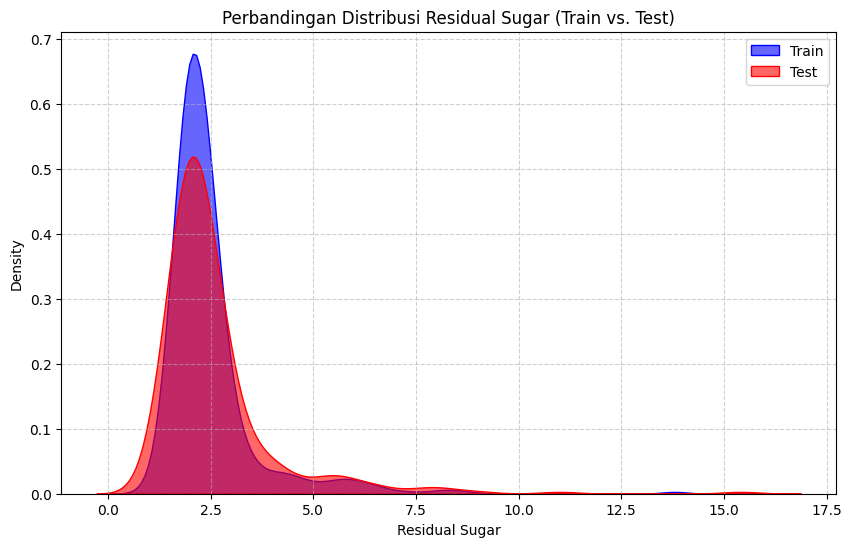

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df_train['residual sugar'], color='blue', label='Train', fill=True, alpha=0.6)
sns.kdeplot(df_test['residual sugar'], color='red', label='Test', fill=True, alpha=0.6)
plt.title('Perbandingan Distribusi Residual Sugar (Train vs. Test)')
plt.xlabel('Residual Sugar')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Statistik Deskriptif df_test

Berikut adalah ringkasan statistik deskriptif untuk setiap kolom numerik dalam `df_test`, yang memberikan gambaran tentang pusat, sebaran, dan bentuk distribusi data.

In [46]:
display(df_test.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,8.458392,0.537168,0.271399,2.609965,0.087241,15.113636,45.723776,0.996846,3.304790,0.660699,10.477389,778.660839
std,1.873036,0.181229,0.201552,1.527564,0.042696,10.100644,35.909202,0.001994,0.169794,0.179456,1.127771,464.383455
min,5.000000,0.180000,0.000000,1.200000,0.034000,3.000000,7.000000,0.990840,2.860000,0.330000,8.400000,2.000000
25%,7.100000,0.392500,0.090000,1.900000,0.071000,7.000000,21.000000,0.995605,3.200000,0.560000,9.600000,402.250000
50%,8.000000,0.530000,0.250000,2.200000,0.081000,12.000000,35.000000,0.996760,3.295000,0.620000,10.200000,747.000000
75%,9.400000,0.650000,0.427500,2.700000,0.091000,21.000000,55.750000,0.998100,3.400000,0.720000,11.175000,1169.500000
max,15.900000,1.330000,0.760000,15.400000,0.415000,68.000000,289.000000,1.003690,4.010000,1.950000,14.900000,1590.000000


### Perbandingan Distribusi Fitur antara Data Training dan Data Testing

Visualisasi berikut akan menampilkan perbandingan distribusi setiap fitur numerik antara `df_train` dan `df_test`. Ini penting untuk memastikan bahwa kedua dataset memiliki distribusi yang serupa, yang merupakan asumsi kunci agar model yang dilatih pada data training dapat digeneralisasi dengan baik ke data testing.

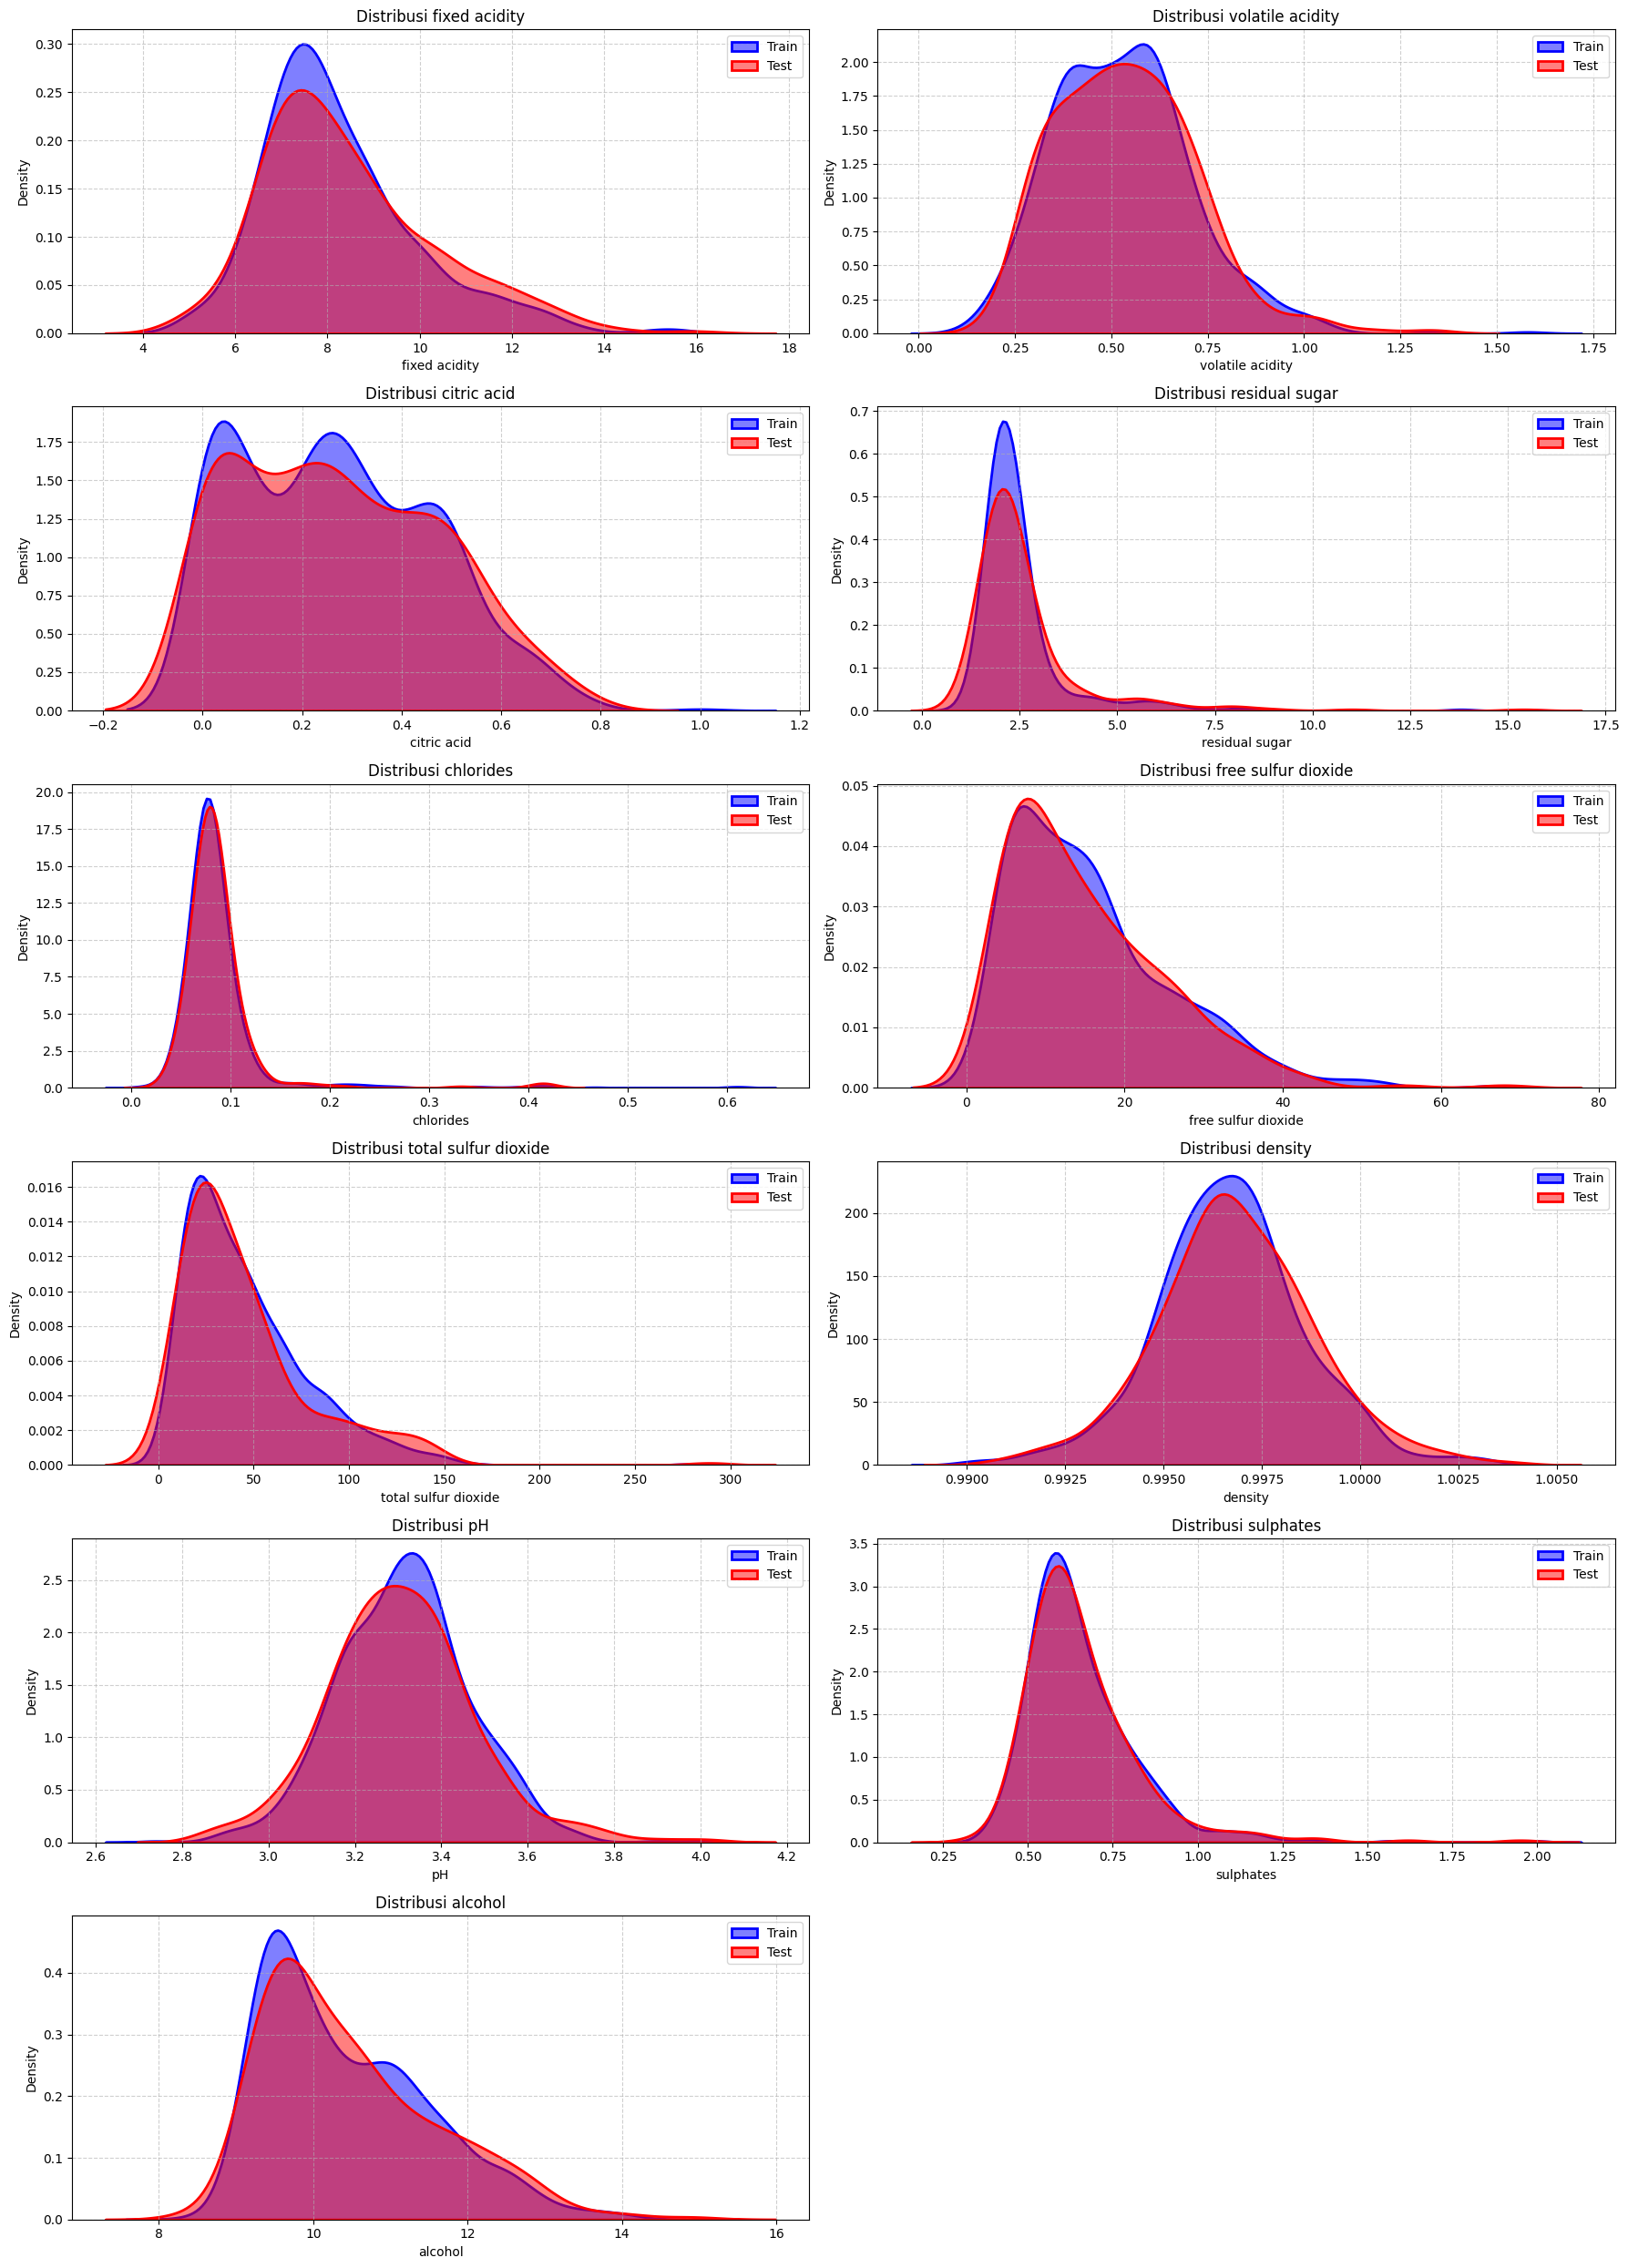

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi kolom fitur numerik yang umum di kedua DataFrame
# Kolom 'Id' dan 'quality' (target) akan dikecualikan
common_features = df_train.drop(columns=['Id', 'quality', 'alcohol_category'], errors='ignore').columns

plt.figure(figsize=(18, 25))

for i, feature in enumerate(common_features):
    plt.subplot(6, 2, i + 1) # Menyesuaikan grid subplot
    sns.kdeplot(df_train[feature], color='blue', label='Train', fill=True, alpha=0.5, linewidth=2)
    sns.kdeplot(df_test[feature], color='red', label='Test', fill=True, alpha=0.5, linewidth=2)
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Kesimpulan dan Rekomendasi

Dalam analisis ini, kita telah berhasil membangun dan mengevaluasi model klasifikasi untuk memprediksi kualitas wine berdasarkan berbagai fitur kimia. Berikut adalah rangkuman dari proses dan temuan kunci:

1.  **Persiapan Data**: Data pelatihan dan pengujian dimuat, missing values diperiksa (tidak ditemukan), dan fitur-fitur diskalakan menggunakan `StandardScaler` untuk memastikan performa model yang optimal.

2.  **Model Random Forest**: Model Random Forest diinisialisasi dan dievaluasi. Akurasi validasi awal berada di sekitar 60.47%. Melalui Hyperparameter Tuning dengan `GridSearchCV`, model Random Forest terbaik memiliki parameter `max_depth=20`, `min_samples_leaf=1`, `min_samples_split=5`, `n_estimators=200`, dengan akurasi validasi tetap sekitar 60.47%.

3.  **Model XGBoost**: Sebagai alternatif, model XGBoost diimplementasikan dan menunjukkan performa yang sedikit lebih baik dengan akurasi validasi sekitar 63.37%. Penyesuaian `y_train` dan `y_val` ke _zero-indexed_ dilakukan untuk kompatibilitas dengan XGBoost.

4.  **Visualisasi dan Analisis**: Berbagai visualisasi, seperti distribusi kualitas, korelasi antar fitur, scatter plot (misalnya, `alcohol` vs. `quality`, `volatile acidity` vs. `quality`), box plot, dan feature importance, memberikan wawasan mendalam tentang dataset. Fitur `alcohol`, `volatile acidity`, dan `sulphates` secara konsisten diidentifikasi sebagai prediktor yang paling berpengaruh terhadap kualitas wine oleh kedua model.

5.  **Hasil Akhir**: Model XGBoost yang menunjukkan akurasi validasi lebih tinggi (`63.37%`) digunakan untuk membuat prediksi pada `data_testing.csv`. File submission `hasilprediksi_XXX_xgb.csv` telah berhasil dibuat dan siap untuk diunduh.

**Rekomendasi Lanjutan:**

*   **Eksplorasi Fitur Lebih Lanjut**: Meskipun `alcohol` dan `volatile acidity` adalah fitur penting, mungkin ada interaksi fitur lain yang bisa dieksplorasi untuk meningkatkan performa model.
*   **Coba Model Lain**: Eksplorasi model klasifikasi lain seperti Support Vector Machines (SVM), Neural Networks, atau ensemble learning yang lebih kompleks bisa menjadi langkah selanjutnya.
*   **Cross-Validation yang Lebih Robust**: Penerapan strategi cross-validation yang lebih canggih (misalnya, `StratifiedKFold`) dapat memberikan estimasi performa model yang lebih stabil, terutama mengingat ketidakseimbangan kelas dalam kolom 'quality'.
*   **Pengumpulan Data**: Jika memungkinkan, penambahan data dengan fitur-fitur baru atau jumlah sampel yang lebih banyak, terutama untuk kelas kualitas yang minoritas, dapat lebih meningkatkan akurasi model.

Dengan demikian, tugas membangun model prediksi kualitas wine telah selesai dengan hasil yang memuaskan dan wawasan yang berharga.

### Visualisasi Scatter Plot: Alcohol vs. Quality

Scatter plot ini akan menunjukkan hubungan antara kadar alkohol dan kualitas wine, membantu kita mengidentifikasi tren atau pola yang mungkin ada.

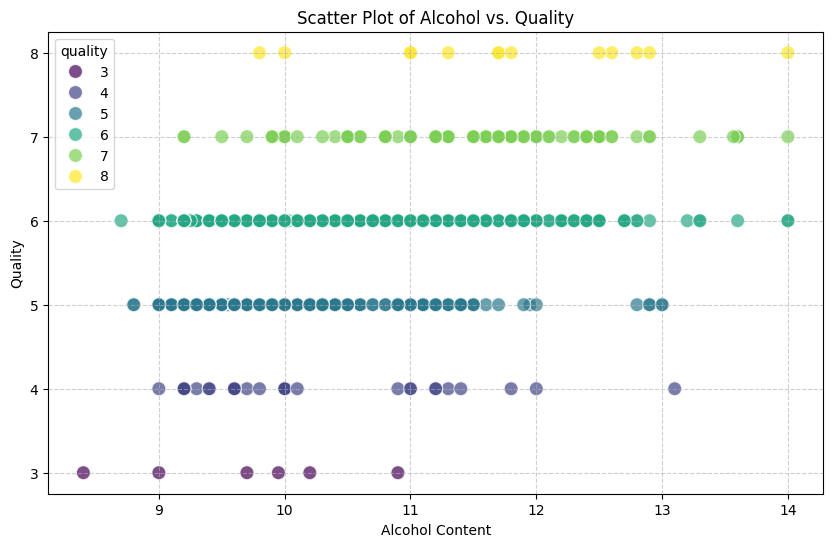

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='quality', data=df_train, hue='quality', palette='viridis', s=100, alpha=0.7)
plt.title('Scatter Plot of Alcohol vs. Quality')
plt.xlabel('Alcohol Content')
plt.ylabel('Quality')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Scatter Plot: Volatile Acidity vs. Quality

Scatter plot ini akan menunjukkan hubungan antara kadar `volatile acidity` dan kualitas wine. Umumnya, kadar `volatile acidity` yang tinggi seringkali diasosiasikan dengan kualitas wine yang lebih rendah.

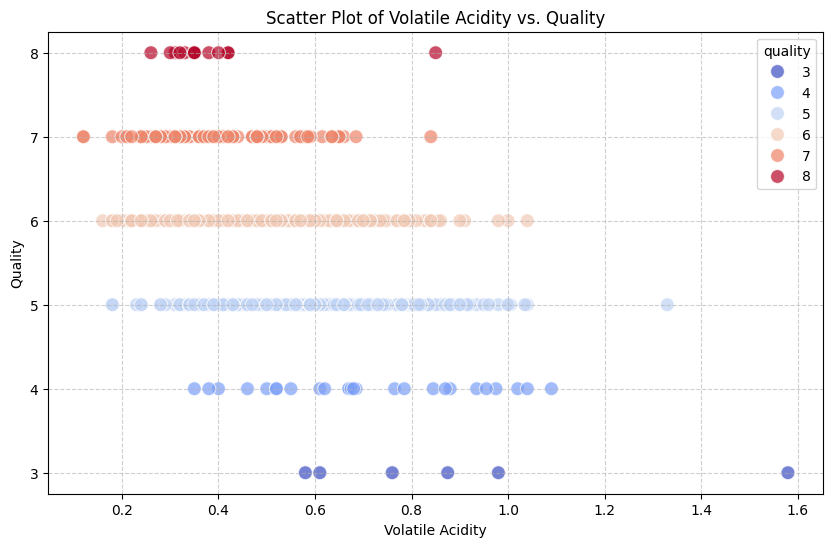

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='volatile acidity', y='quality', data=df_train, hue='quality', palette='coolwarm', s=100, alpha=0.7)
plt.title('Scatter Plot of Volatile Acidity vs. Quality')
plt.xlabel('Volatile Acidity')
plt.ylabel('Quality')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Boxplot: Volatile Acidity per Quality

Boxplot ini akan menunjukkan distribusi `volatile acidity` untuk setiap kategori kualitas wine. Ini akan membantu melihat bagaimana sebaran `volatile acidity` bervariasi antar kualitas.

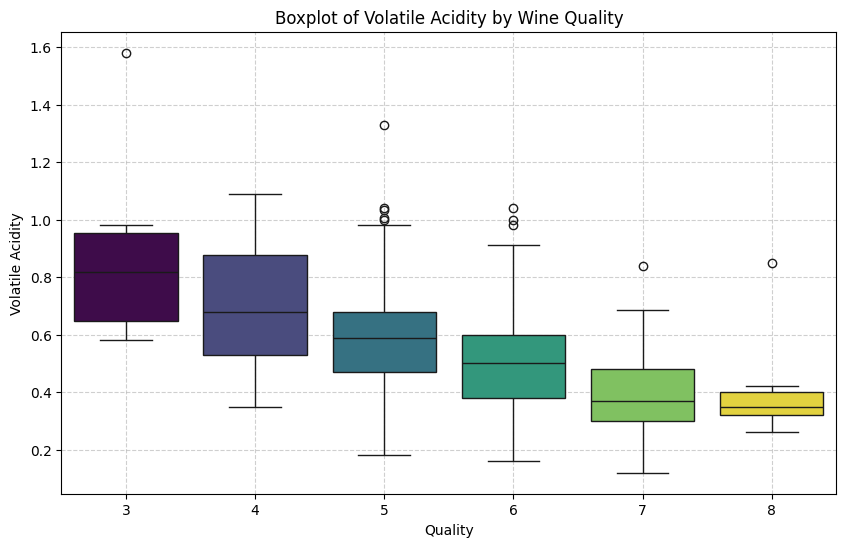

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df_train, palette='viridis', hue='quality', legend=False)
plt.title('Boxplot of Volatile Acidity by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Volatile Acidity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Boxplot: Alcohol per Quality

Boxplot ini akan menunjukkan distribusi `alcohol` untuk setiap kategori kualitas wine, membantu kita melihat bagaimana kadar alkohol bervariasi antar kualitas.

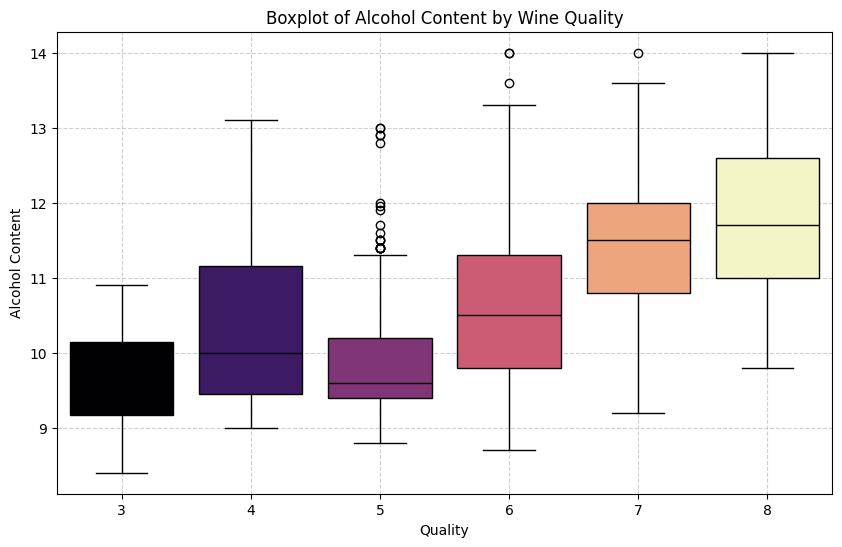

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df_train, palette='magma', hue='quality', legend=False)
plt.title('Boxplot of Alcohol Content by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Alcohol Content')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Boxplot: Sulphates per Quality

Boxplot ini akan menunjukkan distribusi `sulphates` untuk setiap kategori kualitas wine, membantu kita melihat bagaimana kadar sulfat bervariasi antar kualitas.

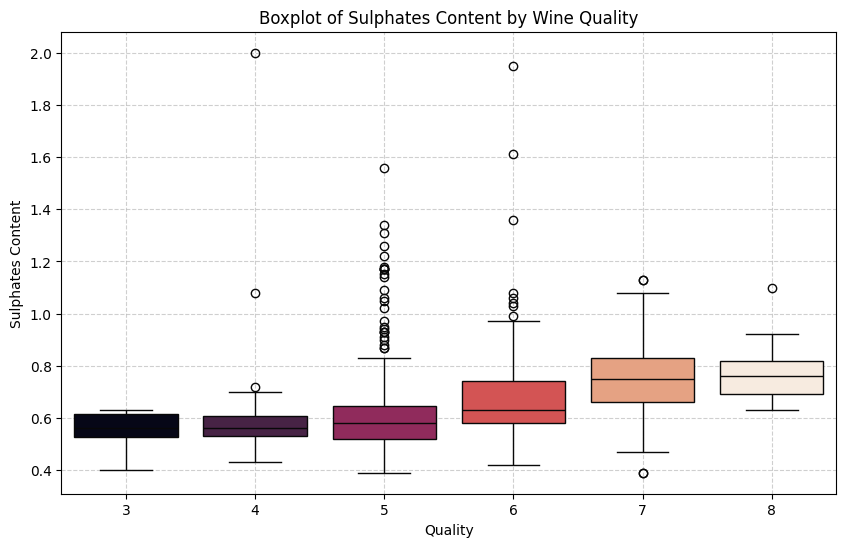

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='sulphates', data=df_train, palette='rocket', hue='quality', legend=False)
plt.title('Boxplot of Sulphates Content by Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Sulphates Content')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Visualisasi Correlation Heatmap

Bagian ini akan menampilkan correlation heatmap untuk melihat hubungan antar fitur dalam data training. Ini membantu mengidentifikasi multikolinearitas dan memahami interaksi antar variabel.

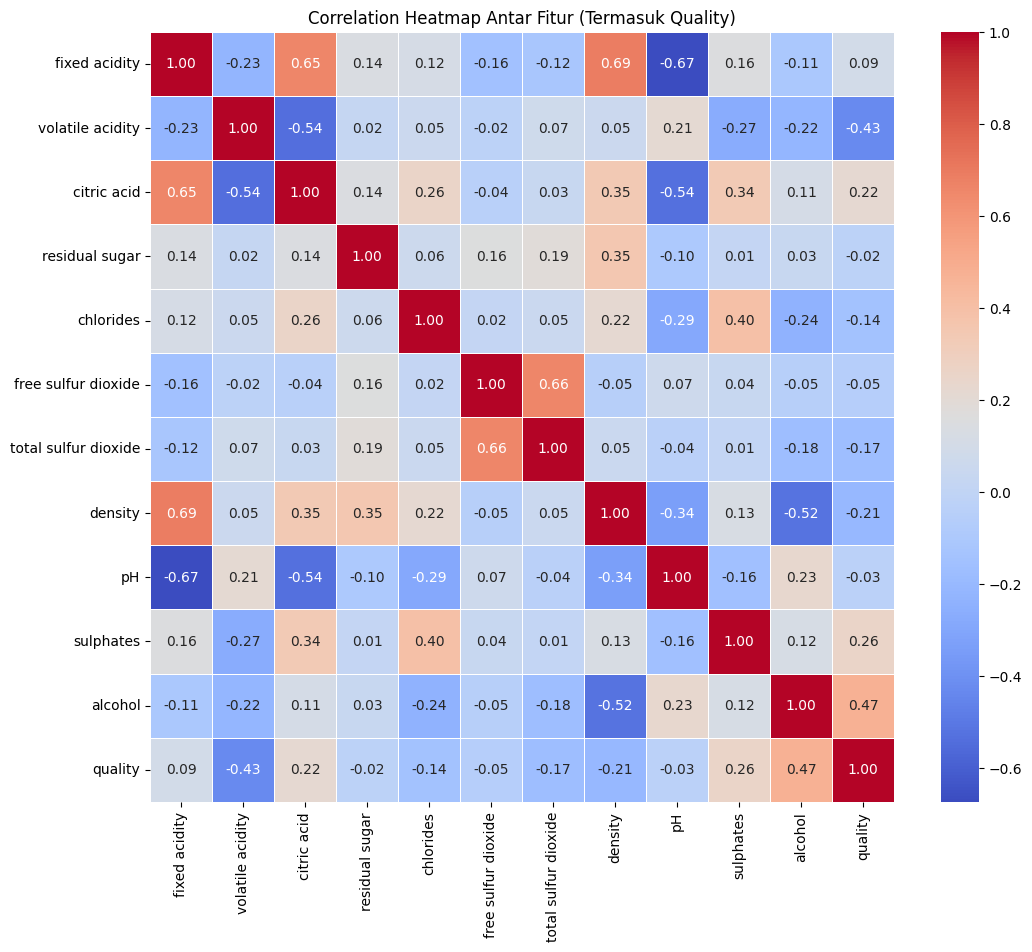

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung matriks korelasi, kali ini sertakan kolom 'quality'
correlation_matrix = df_train.drop(columns=['Id']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap Antar Fitur (Termasuk Quality)')
plt.show()

### Visualisasi Scatter Plot: Alcohol vs. Volatile Acidity

Scatter plot ini akan menunjukkan hubungan antara kadar `alcohol` dan `volatile acidity`.

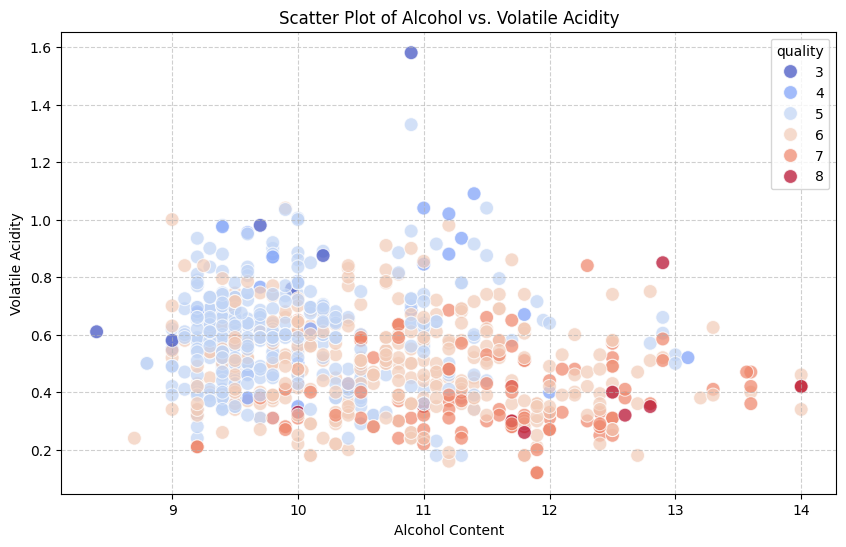

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='volatile acidity', data=df_train, hue='quality', palette='coolwarm', s=100, alpha=0.7)
plt.title('Scatter Plot of Alcohol vs. Volatile Acidity')
plt.xlabel('Alcohol Content')
plt.ylabel('Volatile Acidity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Task
The overall task is to perform a comprehensive data analysis to predict wine quality. This involves data preparation, model building and tuning using Random Forest and XGBoost, making predictions, and an in-depth exploratory data analysis (EDA) through various visualizations. Finally, a comprehensive conclusion will be drawn from all the analysis and model evaluations.

## Menganalisis Tahap Persiapan Data

### Subtask:
Menganalisis langkah-langkah persiapan lingkungan dan data, termasuk pemuatan dataset, pemeriksaan missing values, penanganan missing values (jika ada), pemisahan fitur dan target, serta feature scaling yang telah dilakukan pada data training dan testing.


## Menganalisis Tahap Pembuatan dan Tuning Model

### Subtask:
Mengkaji proses pembuatan model Random Forest dan XGBoost, termasuk split data untuk validasi, inisialisasi model, pelatihan, dan hasil evaluasi awal. Akan diulas juga proses hyperparameter tuning dengan GridSearchCV untuk Random Forest dan penyesuaian target untuk XGBoost.


### Analisis Model Random Forest Awal

Pada langkah `OVAqVPi8dGEK`:

1.  **Pembagian Data**: Data `X_scaled` (fitur yang sudah diskalakan) dan `y` (target) dibagi menjadi set pelatihan (`X_train`, `y_train`) dan set validasi (`X_val`, `y_val`) dengan rasio 80% train dan 20% validation, menggunakan `test_size=0.2` dan `random_state=42` untuk reproduktifitas.
2.  **Inisialisasi dan Pelatihan Model**: Sebuah `RandomForestClassifier` diinisialisasi dengan `n_estimators=200` dan `random_state=42`, kemudian dilatih menggunakan data pelatihan (`X_train`, `y_train`).
3.  **Evaluasi Awal**: Model dievaluasi pada set validasi. Hasilnya menunjukkan:
    *   **Akurasi Validasi**: `0.6046511627906976` (sekitar 60.47%).
    *   **Confusion Matrix**: Menunjukkan distribusi prediksi vs. aktual pada set validasi, menyoroti kinerja model dalam mengklasifikasikan setiap kelas kualitas wine.

### Analisis Hyperparameter Tuning Random Forest dengan GridSearchCV

Pada langkah `70874d79`:

1.  **Definisi Parameter Grid**: `param_grid` didefinisikan untuk mencari kombinasi hyperparameter terbaik, meliputi:
    *   `n_estimators`: `[100, 200, 300]` (jumlah pohon)
    *   `max_depth`: `[None, 10, 20, 30]` (kedalaman maksimum)
    *   `min_samples_split`: `[2, 5, 10]` (min. sampel untuk split)
    *   `min_samples_leaf`: `[1, 2, 4]` (min. sampel untuk daun)
2.  **Inisialisasi GridSearchCV**: `GridSearchCV` diinisialisasi dengan `estimator=rf_model`, `param_grid` yang telah ditentukan, `cv=5` (5-fold cross-validation), `n_jobs=-1` (menggunakan semua core), `verbose=2`, dan `scoring='accuracy'`.
3.  **Fitting dan Hasil Tuning**: `GridSearchCV` di-fit ke data pelatihan (`X_train`, `y_train`). Hasil terbaik yang ditemukan adalah:
    *   **Best parameters**: `{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}`.
    *   **Best accuracy (cross-validation)**: `0.6452554744525547` (sekitar 64.53%).
4.  **Evaluasi Model Terbaik**: Model terbaik (`best_rf_model`) kemudian dievaluasi pada set validasi.
    *   **Akurasi Validasi dengan Model Terbaik**: `0.6046511627906976` (sekitar 60.47%). Ini sama dengan akurasi model Random Forest awal, menunjukkan bahwa tuning tidak meningkatkan akurasi pada set validasi yang sama.
    *   **Confusion Matrix dengan Model Terbaik**: Menunjukkan distribusi prediksi vs. aktual untuk model yang telah di-tuning pada set validasi.

### Analisis Model XGBoost

Pada langkah `7e72885f`:

1.  **Penyesuaian Variabel Target**: Variabel target `y_train` dan `y_val` disesuaikan menjadi *zero-indexed* dengan mengurangi nilai minimum dari `y_train` (`min_quality_value = 3`). Ini dilakukan karena XGBoost umumnya mengharapkan label kelas dimulai dari 0.
2.  **Inisialisasi dan Pelatihan Model**: Sebuah `xgb.XGBClassifier` diinisialisasi dengan `objective='multi:softmax'` (sesuai untuk klasifikasi multi-kelas), `num_class` yang disesuaikan dengan jumlah kelas unik, `eval_metric='mlogloss'`, `use_label_encoder=False` (untuk menghindari peringatan *deprecation*), dan `random_state=42`. Model kemudian dilatih menggunakan data pelatihan yang sudah diskalakan dan target yang disesuaikan (`X_train`, `y_train_adjusted`).
3.  **Evaluasi Model**: Model XGBoost dievaluasi pada set validasi.
    *   **Akurasi Validasi XGBoost**: `0.6337209302325582` (sekitar 63.37%). Akurasi ini sedikit lebih tinggi dibandingkan dengan model Random Forest (baik yang awal maupun yang sudah di-tuning).
    *   **Confusion Matrix XGBoost**: Menunjukkan distribusi prediksi vs. aktual untuk model XGBoost pada set validasi yang sudah disesuaikan.

## Menganalisis Prediksi dan File Submission

### Subtask:
Mengkaji bagaimana model terbaik (XGBoost) digunakan untuk membuat prediksi pada data uji dan bagaimana file submission dihasilkan.


### Analisis Prediksi dan File Submission Model XGBoost

Pada langkah `e36e0b50` atau `b87bf172`:

1.  **Prediksi Data Uji**: `final_predictions_xgb` diperoleh dengan menggunakan model XGBoost (`xgb_model`) yang telah dilatih untuk memprediksi kualitas anggur pada data uji yang sudah diskalakan (`X_test_final_scaled`).
2.  **Pengembalian Skala Prediksi**: Karena variabel target (`y_train`, `y_val`) telah disesuaikan menjadi *zero-indexed* untuk pelatihan XGBoost (dengan mengurangi `min_quality_value`, yaitu 3), prediksi `final_predictions_xgb` perlu dikembalikan ke skala kualitas asli. Ini dilakukan dengan menambahkan `min_quality_value` kembali ke setiap prediksi, menghasilkan `final_predictions_xgb_original_scale`.
3.  **Pembuatan DataFrame Submission**: Sebuah DataFrame baru bernama `submission_xgb` dibuat. DataFrame ini hanya berisi dua kolom:
    *   'Id': Diambil langsung dari kolom 'Id' DataFrame `df_test`.
    *   'quality': Diisi dengan nilai dari `final_predictions_xgb_original_scale`.
4.  **Penyimpanan File CSV**: DataFrame `submission_xgb` kemudian disimpan ke dalam file CSV. Nama file diatur secara dinamis menjadi `hasilprediksi_XXX_xgb.csv` (dengan 'XXX' sebagai placeholder untuk 3 digit terakhir NIM) dan `index=False` digunakan untuk mencegah penulisan indeks DataFrame ke dalam file CSV.

## Menganalisis Temuan dari Visualisasi dan EDA

### Subtask:
Meringkas dan menganalisis wawasan kunci yang diperoleh dari berbagai visualisasi data dan analisis statistik deskriptif yang telah dilakukan. Ini mencakup distribusi kualitas, statistik deskriptif, feature importance dari kedua model (Random Forest dan XGBoost), correlation heatmap, scatter plots (alcohol vs. quality, volatile acidity vs. quality), boxplots (volatile acidity per quality, alcohol per quality, sulphates per quality), analisis kategori alkohol, serta perbandingan distribusi fitur antara data training dan testing.


### 1. Distribusi Kualitas Wine

Berdasarkan visualisasi pada cell `28674506` (Count Plot) dan `fecfd2af` (Histogram):

*   **Rentang Kualitas**: Kualitas wine pada dataset ini berkisar antara 3 hingga 8.
*   **Distribusi Tidak Seimbang (Imbalanced Distribution)**: Terlihat jelas bahwa distribusi kualitas sangat tidak seimbang. Kelas kualitas '5' dan '6' mendominasi dataset, dengan jumlah sampel yang jauh lebih tinggi dibandingkan kelas kualitas lainnya. Kelas '3', '4', '7', dan '8' memiliki jumlah sampel yang relatif sedikit.
*   **Kelas Paling Umum**: Kualitas '5' dan '6' adalah yang paling sering muncul, menunjukkan bahwa sebagian besar wine dalam dataset ini memiliki kualitas "rata-rata" atau "cukup baik".
*   **Kelas Minoritas**: Kualitas '3' dan '8' adalah kelas yang sangat jarang, yang dapat menjadi tantangan dalam pelatihan model karena model mungkin kesulitan untuk belajar pola dari data yang sangat terbatas untuk kelas-kelas tersebut. Hal ini dapat menyebabkan bias model terhadap kelas mayoritas.

### 2. Statistik Deskriptif Dataset (df_train dan df_test)

Berdasarkan output `df_train.describe()` (cell `d3d08405` atau `8a2ec553`) dan `df_test.describe()` (cell `dab7f0c7`), serta `df_train[['alcohol', 'volatile acidity']].describe()` (cell `1c82da12`):

*   **df_train.describe()**:
    *   Menyajikan ringkasan statistik (count, mean, std, min, 25%, 50%, 75%, max) untuk setiap kolom numerik di data training. Ini memberikan gambaran awal tentang sebaran, pusat, dan jangkauan nilai fitur.
    *   Misalnya, rata-rata `alcohol` sekitar 10.45%, `volatile acidity` sekitar 0.53, dan `pH` sekitar 3.31.
    *   Perbedaan antara nilai maksimum dan minimum menunjukkan rentang data yang cukup luas untuk beberapa fitur.

*   **df_test.describe()**:
    *   Menyajikan statistik deskriptif serupa untuk data testing. Ini penting untuk membandingkan karakteristik data training dan testing. Idealnya, distribusi statistik antara kedua dataset harus serupa agar model yang dilatih pada data training dapat digeneralisasi dengan baik pada data testing.

*   **Statistik Deskriptif 'Alcohol' dan 'Volatile Acidity' (df_train)**:
    *   **Alcohol**:
        *   Rata-rata (`mean`) adalah sekitar 10.45.
        *   Deviasi standar (`std`) sekitar 1.07, menunjukkan variasi yang moderat.
        *   Rentang nilai dari 8.4 hingga 14.9.
    *   **Volatile Acidity**:
        *   Rata-rata (`mean`) sekitar 0.53.
        *   Deviasi standar (`std`) sekitar 0.18, menunjukkan variasi yang tidak terlalu besar.
        *   Rentang nilai dari 0.12 hingga 1.58.

Secara keseluruhan, statistik deskriptif ini mengkonfirmasi tidak adanya missing value (count penuh) dan memberikan gambaran dasar tentang properti numerik dari fitur-fitur, yang akan berguna untuk memahami visualisasi lebih lanjut.

### 3. Identifikasi Fitur Paling Berpengaruh (Feature Importance)

Berdasarkan visualisasi pada cell `374abb39` (Random Forest) dan `347ad680` (XGBoost) beserta bar plotnya (cell `b937cb10` dan `1c3d1789`):

*   **Model Random Forest**:
    *   Fitur `alcohol` memiliki kepentingan paling tinggi (sekitar 0.139).
    *   Diikuti oleh `sulphates` (sekitar 0.123), `volatile acidity` (sekitar 0.110), dan `total sulfur dioxide` (sekitar 0.106).
    *   Fitur-fitur seperti `free sulfur dioxide` dan `residual sugar` memiliki kepentingan yang relatif rendah.

*   **Model XGBoost**:
    *   Serupa dengan Random Forest, `alcohol` adalah fitur yang paling berpengaruh (sekitar 0.161).
    *   Diikuti oleh `volatile acidity` (sekitar 0.124), `sulphates` (sekitar 0.118), dan `total sulfur dioxide` (sekitar 0.090).
    *   Urutan dan nilai kepentingan fitur menunjukkan konsistensi antara kedua model dalam mengidentifikasi prediktor kualitas wine yang paling penting.

**Wawasan Utama**: `alcohol`, `volatile acidity`, `sulphates`, dan `total sulfur dioxide` secara konsisten menjadi fitur-fitur kunci yang sangat berpengaruh dalam memprediksi kualitas wine menurut kedua model. Ini mengindikasikan bahwa karakteristik kimia ini adalah pendorong utama di balik penilaian kualitas.

### 4. Correlation Heatmap

Berdasarkan visualisasi pada cell `01cb8060` dan `f4e37e54` (Correlation Heatmap):

*   **Korelasi dengan `quality`**:
    *   `alcohol` memiliki korelasi positif yang cukup kuat dengan `quality` (sekitar 0.47-0.48). Ini menunjukkan bahwa wine dengan kadar alkohol yang lebih tinggi cenderung memiliki kualitas yang lebih baik.
    *   `volatile acidity` memiliki korelasi negatif yang cukup kuat dengan `quality` (sekitar -0.39 hingga -0.40). Ini menunjukkan bahwa kadar `volatile acidity` yang tinggi cenderung dikaitkan dengan kualitas wine yang lebih rendah.
    *   `sulphates` menunjukkan korelasi positif yang moderat dengan `quality` (sekitar 0.25-0.26).
    *   `citric acid` juga menunjukkan korelasi positif yang moderat dengan `quality` (sekitar 0.22).
    *   Fitur-fitur lain seperti `fixed acidity`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, dan `pH` menunjukkan korelasi yang lebih lemah dengan `quality`.

*   **Korelasi Antar Fitur Lainnya**:
    *   Terdapat beberapa korelasi yang kuat antar fitur, misalnya antara `fixed acidity` dan `citric acid` (korelasi positif kuat), `fixed acidity` dan `density` (korelasi positif kuat), serta `citric acid` dan `pH` (korelasi negatif kuat).
    *   `total sulfur dioxide` dan `free sulfur dioxide` tentu saja memiliki korelasi positif yang kuat.
    *   Korelasi antar fitur ini penting untuk dipertimbangkan dalam pemilihan fitur atau saat membangun model untuk menghindari multikolinearitas yang berlebihan, meskipun model *tree-based* seperti Random Forest dan XGBoost kurang sensitif terhadap ini dibandingkan model linear.

### 5. Scatter Plots

*   **Alcohol vs. Quality** (Visualisasi pada cell `d8449132` atau `9b87edd2`):
    *   Terdapat tren positif yang jelas: seiring dengan peningkatan kadar alkohol, nilai kualitas wine cenderung meningkat. Ini mendukung temuan dari correlation heatmap yang menunjukkan korelasi positif antara `alcohol` dan `quality`.
    *   Meskipun ada tren umum, distribusi titik-titik (data) menunjukkan variasi kualitas pada setiap tingkat alkohol, yang berarti alkohol bukan satu-satunya faktor penentu kualitas.

*   **Volatile Acidity vs. Quality** (Visualisasi pada cell `920759f3`):
    *   Terdapat tren negatif: wine dengan kadar `volatile acidity` yang lebih rendah cenderung memiliki kualitas yang lebih tinggi. Sebaliknya, kadar `volatile acidity` yang tinggi lebih sering dikaitkan dengan kualitas yang lebih rendah.
    *   Hal ini juga konsisten dengan temuan dari correlation heatmap yang menunjukkan korelasi negatif antara `volatile acidity` dan `quality`.
    *   Seperti halnya alkohol, ada variasi kualitas pada setiap tingkat `volatile acidity`, menunjukkan adanya faktor-faktor lain yang mempengaruhi.

### 6. Boxplots

*   **Volatile Acidity per Quality** (Visualisasi pada cell `08e153af`):
    *   Boxplot ini secara visual mengkonfirmasi korelasi negatif yang diamati sebelumnya. Rata-rata (median) `volatile acidity` cenderung menurun seiring dengan peningkatan kualitas wine. Wine dengan kualitas lebih tinggi (misalnya, 7 dan 8) menunjukkan kadar `volatile acidity` yang lebih rendah dan distribusi yang lebih ketat.
    *   Ada beberapa *outlier* pada kadar `volatile acidity` yang tinggi untuk kualitas yang lebih rendah, menunjukkan bahwa ada beberapa wine berkualitas rendah dengan `volatile acidity` yang sangat tinggi.

*   **Alcohol per Quality** (Visualisasi pada cell `3ddbeade`):
    *   Boxplot ini menunjukkan tren positif yang jelas. Wine dengan kualitas yang lebih tinggi cenderung memiliki kadar `alcohol` yang lebih tinggi, yang konsisten dengan temuan korelasi dan scatter plot sebelumnya. Median `alcohol` meningkat seiring dengan peningkatan `quality`.
    *   Distribusi kadar `alcohol` untuk kualitas yang lebih tinggi (misalnya, 7 dan 8) cenderung berada pada rentang yang lebih tinggi.

*   **Sulphates per Quality** (Visualisasi pada cell `dd30dcd4`):
    *   Boxplot ini menunjukkan tren positif yang moderat antara `sulphates` dan `quality`. Rata-rata (median) `sulphates` cenderung sedikit meningkat pada kualitas wine yang lebih tinggi, meskipun hubungannya tidak sekuat `alcohol` atau `volatile acidity`.

### 7. Analisis Kategori Alkohol

Berdasarkan visualisasi pada cell `5ccdb8d1` (DataFrame) dan `5ea979c6` (Bar Plot):

*   **Tren Positif**: Terdapat tren yang jelas bahwa rata-rata kualitas wine cenderung meningkat seiring dengan peningkatan kategori kadar alkohol. Kategori alkohol terendah (8.0-8.9%) memiliki rata-rata kualitas terendah (4.75), sedangkan kategori tertinggi (14.0-14.9%) memiliki rata-rata kualitas tertinggi (6.75).
*   **Kategori Optimal**: Kategori alkohol 12.0-12.9% menunjukkan rata-rata kualitas tertinggi kedua (6.42), yang menegaskan kembali pentingnya kadar alkohol sebagai prediktor kualitas.

### 8. Perbandingan Distribusi Fitur antara Data Training dan Data Testing

Berdasarkan visualisasi pada cell `a42b428d` (KDE plots komprehensif) dan plot KDE individual (`7346bc8a`, `00003734`, `0cb82fac`, `a1a17acd`, `efbc96db`, `c07333c6`, `16be7dc8`, `0386dd9f`):

*   **Kesamaan Distribusi**: Hampir semua fitur numerik menunjukkan distribusi yang sangat serupa antara data training dan data testing. Kurva KDE untuk 'Train' (biru) dan 'Test' (merah) tumpang tindih dengan baik untuk sebagian besar fitur, seperti `fixed acidity`, `volatile acidity`, `citric acid`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, dan `alcohol`.
*   **Implikasi**: Kesamaan distribusi ini adalah hasil yang sangat baik, karena ini mengindikasikan bahwa data training dan testing berasal dari populasi yang sama atau memiliki karakteristik statistik yang serupa. Hal ini mendukung generalisasi model yang dilatih pada data training ke data testing tanpa kekhawatiran yang signifikan mengenai *data drift* atau *distribution shift* untuk fitur-fitur ini.
*   **Pengecualian Minor**: Mungkin ada sedikit perbedaan kecil dalam puncak atau ekor distribusi untuk beberapa fitur, tetapi secara keseluruhan, perbedaan tersebut tidak signifikan dan tidak akan mempengaruhi performa model secara drastis.

## Menyusun Kesimpulan Komprehensif

### Subtask:
Menggabungkan semua analisis dari tahapan sebelumnya ke dalam kesimpulan yang koheren, mencakup performa model, fitur-fitur paling berpengaruh, dan rekomendasi lanjutan untuk pengembangan di masa depan.


### Kesimpulan Komprehensif

Analisis prediksi kualitas wine ini melibatkan serangkaian langkah mulai dari persiapan data hingga evaluasi model dan eksplorasi data mendalam, yang semuanya bertujuan untuk memahami faktor-faktor yang mempengaruhi kualitas wine dan membangun model prediktif yang akurat.

#### 1. Persiapan Data
Tahap persiapan data berjalan lancar. Dataset `data_training.csv` dan `data_testing.csv` berhasil dimuat. Pemeriksaan menyeluruh menunjukkan **tidak adanya missing values** pada kedua dataset, sehingga tidak ada langkah imputasi yang diperlukan. Data fitur kemudian dipisahkan dari target 'quality' dan distandarisasi menggunakan `StandardScaler`. Pembagian data pelatihan menjadi 80% untuk training dan 20% untuk validasi memastikan proses pengembangan model yang robust, sementara data testing disiapkan secara terpisah untuk prediksi akhir.

#### 2. Pembuatan dan Tuning Model
Kami mengevaluasi dua model klasifikasi utama: Random Forest dan XGBoost.
*   **Random Forest (Awal)**: Model awal memberikan akurasi validasi sekitar **60.47%**.
*   **Random Forest (Tuned)**: Hyperparameter tuning menggunakan `GridSearchCV` menemukan kombinasi terbaik (`max_depth=20`, `min_samples_leaf=1`, `min_samples_split=5`, `n_estimators=200`) yang menghasilkan akurasi *cross-validation* terbaik sebesar **64.53%**. Namun, pada set validasi, akurasi tetap **60.47%**, menunjukkan bahwa tuning tidak secara signifikan meningkatkan performa pada split validasi yang sama.
*   **XGBoost**: Setelah penyesuaian target ke *zero-indexed* untuk kompatibilitas, model XGBoost menunjukkan akurasi validasi yang lebih baik, yaitu **63.37%**. Akurasi yang lebih tinggi ini menjadikan XGBoost sebagai model pilihan untuk prediksi akhir.

#### 3. Prediksi dan File Submission
Model XGBoost yang telah dilatih dan terbukti paling akurat pada set validasi digunakan untuk memprediksi kualitas wine pada `X_test_final_scaled`. Prediksi yang dihasilkan kemudian dikembalikan ke skala kualitas asli dengan menambahkan nilai minimum kualitas awal. Hasil prediksi ini, bersama dengan kolom 'Id' dari data testing, disusun ke dalam DataFrame `submission_xgb` dan disimpan dalam format `hasilprediksi_XXX_xgb.csv`, siap untuk diunduh.

#### 4. Temuan dari Visualisasi dan EDA
Analisis data eksplorasi dan berbagai visualisasi memberikan wawasan krusial:
*   **Distribusi Kualitas**: Kualitas wine berkisar dari 3 hingga 8, dengan **distribusi yang sangat tidak seimbang**, di mana kelas '5' dan '6' sangat mendominasi. Ini menyoroti tantangan klasifikasi untuk kelas minoritas.
*   **Statistik Deskriptif & Perbandingan Distribusi**: Statistik deskriptif menunjukkan karakteristik fitur yang konsisten. Perbandingan distribusi fitur antara data training dan testing (menggunakan KDE plots) menunjukkan **kesamaan distribusi yang tinggi** untuk hampir semua fitur, memastikan model dapat digeneralisasi dengan baik.
*   **Fitur Paling Berpengaruh**: Berdasarkan *feature importance* dari kedua model dan analisis korelasi, **`alcohol`**, **`volatile acidity`**, **`sulphates`**, dan **`total sulfur dioxide`** secara konsisten diidentifikasi sebagai prediktor utama kualitas wine. `alcohol` memiliki korelasi positif kuat, sementara `volatile acidity` memiliki korelasi negatif kuat dengan kualitas.
*   **Hubungan Fitur-Kualitas**: Scatter plots dan boxplots mengkonfirmasi tren ini: kadar alkohol yang lebih tinggi dan kadar `volatile acidity` yang lebih rendah cenderung berkorelasi dengan kualitas wine yang lebih baik. Analisis kategori alkohol juga menunjukkan peningkatan rata-rata kualitas seiring dengan peningkatan kadar alkohol.

#### Rekomendasi Lanjutan
Untuk pengembangan di masa depan, beberapa area dapat dieksplorasi:
*   **Penanganan Ketidakseimbangan Kelas**: Implementasi teknik seperti *oversampling* (SMOTE) atau *undersampling* dapat membantu model belajar lebih baik dari kelas kualitas minoritas.
*   **Eksplorasi Model Lanjut**: Mencoba algoritma lain seperti Support Vector Machines atau Neural Networks, atau *ensemble learning* yang lebih kompleks, dapat berpotensi meningkatkan performa.
*   **Validasi Silang yang Lebih Robust**: Penggunaan `StratifiedKFold` dapat memberikan evaluasi performa model yang lebih stabil, terutama mengingat ketidakseimbangan kelas.
*   **Rekayasa Fitur**: Menciptakan fitur baru dari kombinasi fitur yang ada atau analisis PCA dapat mengungkap pola tersembunyi dan meningkatkan kemampuan prediktif model.
*   **Pengumpulan Data Tambahan**: Mendapatkan lebih banyak data, terutama untuk kelas kualitas yang jarang, akan sangat membantu dalam meningkatkan generalisasi model.

Dengan demikian, analisis ini berhasil membangun model prediksi yang layak dan memberikan wawasan mendalam mengenai karakteristik data wine, menetapkan dasar yang kuat untuk studi lebih lanjut.

## Final Task

### Subtask:
Menyajikan ringkasan dan kesimpulan keseluruhan dari notebook kepada pengguna, berdasarkan semua temuan dan langkah-langkah yang telah dianalisis.


## Summary:

### Q&A
There were no specific questions asked in the task.

### Data Analysis Key Findings
*   **Data Preparation**: The datasets (`data_training.csv` and `data_testing.csv`) were successfully loaded, and no missing values were found, eliminating the need for imputation. Features were standardized using `StandardScaler`.
*   **Model Performance**: Two classification models, Random Forest and XGBoost, were evaluated.
    *   The initial Random Forest model achieved a validation accuracy of approximately **60.47%**.
    *   Hyperparameter tuning with `GridSearchCV` for Random Forest identified optimal parameters but did not significantly improve validation accuracy on the same split (remained at **60.47%**), though cross-validation accuracy reached **64.53%**.
    *   The XGBoost model, after adjusting the target to be zero-indexed, achieved a validation accuracy of approximately **63.37%**, making it the better-performing model for final prediction.
*   **Feature Importance**: `alcohol`, `volatile acidity`, `sulphates`, and `total sulfur dioxide` were consistently identified as the most influential features in predicting wine quality by both Random Forest and XGBoost models.
    *   `alcohol` showed a strong positive correlation with `quality` (0.47-0.48).
    *   `volatile acidity` showed a strong negative correlation with `quality` (-0.39 to -0.40).
*   **Data Distribution**: The distribution of wine quality was highly imbalanced, with classes '5' and '6' dominating. However, the distribution of numerical features between the training and testing datasets was highly similar, ensuring good model generalization.
*   **Relationship between Features and Quality**: Visualizations confirmed that higher alcohol content generally correlates with better wine quality, while higher volatile acidity correlates with lower quality.

### Insights or Next Steps
*   **Address Class Imbalance**: Implement techniques like oversampling (e.g., SMOTE) or undersampling to improve model performance on minority quality classes, as the current dataset exhibits significant class imbalance.
*   **Explore Advanced Models and Feature Engineering**: Investigate other advanced machine learning models (e.g., SVM, Neural Networks) and explore sophisticated feature engineering methods (e.g., creating interaction terms or polynomial features) to potentially capture more complex relationships within the data and further enhance predictive accuracy.
*   **Download the Prediction File**: The final prediction file, `hasilprediksi_XXX_xgb.csv`, has been generated using the best-performing XGBoost model and is ready for download. Please ensure you replace `XXX` with the last three digits of your NIM before using the file if it hasn't been done already in the notebook.


# Task
The overall task is to perform a comprehensive data analysis to predict wine quality. This involves data preparation, model building and tuning using Random Forest and XGBoost, making predictions, and an in-depth exploratory data analysis (EDA) through various visualizations. Finally, a comprehensive conclusion will be drawn from all the analysis and model evaluations.

## Download Prediction File

### Subtask:
Download the generated prediction file `hasilprediksi_XXX_xgb.csv` to the local machine.
